In [ ]:
'''
All the equations are taken from Pasta by Design book by George L. Legendre
Author: Ali Fuat Sahin, Jack Chen
'''

import numpy as np
import trimesh
from scipy.spatial import Delaunay
import pymeshlab
import os

In [ ]:
save_mesh = False
extension = 'stl'
save_path = './data/'

visualize = True
dims = {}

In [3]:
def pasta_creator(Π, Θ, Κ, i_max, j_max):
    # Create a grid of i and j
    i = np.linspace(0, i_max, i_max + 1)
    j = np.linspace(0, j_max, j_max + 1)
    i, j = np.meshgrid(i, j)
    
    # Flatten the grid for easier processing
    i_flat, j_flat = i.ravel(), j.ravel()
    
    # Compute x, y, z coordinates
    x = Π(i_flat, j_flat)
    y = Θ(i_flat, j_flat)
    z = Κ(i_flat, j_flat)
    
    # Combine into vertices
    vertices = np.column_stack((x, y, z))
    
    # Triangulate the grid in the (i, j) space
    tri = Delaunay(np.column_stack((i_flat, j_flat)))
    
    # Use the triangulation to create faces
    faces = tri.simplices
    
    # Create the mesh
    mesh = trimesh.Trimesh(vertices=vertices, faces=faces)

    # mesh = pymeshlab.Mesh(vertices, faces)

    # mesh = o3d.geometry.TriangleMesh()
    # mesh.vertices = o3d.utility.Vector3dVector(vertices)
    # mesh.triangles = o3d.utility.Vector3iVector(faces)

    return mesh

In [4]:
def add_thickness(mesh, thickness):
    # Calculate vertex normals
    normals = mesh.vertex_normals
    
    # Create inner and outer vertices
    inner_vertices = mesh.vertices - normals * (thickness / 2)
    outer_vertices = mesh.vertices + normals * (thickness / 2)
    
    # Apply Laplacian smoothing to inner vertices
    # inner_vertices = laplacian_smoothing(inner_vertices, mesh.faces)
    
    # Combine inner and outer vertices
    vertices = np.vstack((inner_vertices, outer_vertices))
    
    # Create faces for the side walls
    side_faces = []
    for face in mesh.faces:
        for i in range(3):
            next_i = (i + 1) % 3
            side_faces.append([face[i], face[next_i], face[next_i] + len(mesh.vertices)])
            side_faces.append([face[i], face[next_i] + len(mesh.vertices), face[i] + len(mesh.vertices)])
    
    # Combine all faces
    faces = np.vstack((mesh.faces, mesh.faces + len(mesh.vertices), side_faces))
    
    # Create a new mesh with the new vertices and faces
    new_mesh = trimesh.Trimesh(vertices=vertices, faces=faces)
    return new_mesh

In [5]:
def scale_mesh_to_dimensions(mesh, target_length, target_width, target_height):
    # Calculate the bounding box of the mesh
    bounding_box = mesh.bounding_box.extents
    
    # Determine the current dimensions of the mesh
    current_length, current_width, current_height = bounding_box

    print(f"Current dimensions: Length={current_length}, Width={current_width}, Height={current_height}")

    # current_length = mesh.bounding_box().dim_x()
    # current_width = mesh.bounding_box().dim_y()
    # current_height = mesh.bounding_box().dim_z()

    # bbox = mesh.get_axis_aligned_bounding_box()
    # current_length, current_width, current_height = bbox.get_extent()  # [x_length, y_length, z_length]
    
    # Calculate the scaling factors for each dimension
    scale_factor_length = 1 if current_length == 0 else target_length / current_length
    scale_factor_width = 1 if current_width == 0 else target_width / current_width
    scale_factor_height = 1 if current_height == 0 else target_height / current_height

    vertices = np.asarray(mesh.vertices)
    center = mesh.centroid
    vertices -= center
    
    # Scale the vertices of the mesh
    # scaled_vertices = mesh.vertices * [scale_factor_length, scale_factor_width, scale_factor_height]
    scaled_vertices = vertices * [scale_factor_length, scale_factor_width, scale_factor_height]

    scaled_vertices += center
    
    # Create a new mesh with the scaled vertices and the same faces
    scaled_mesh = trimesh.Trimesh(vertices=scaled_vertices, faces=mesh.faces)

    scaled_length, scaled_width, scaled_height = scaled_mesh.bounding_box.extents

    print(f"Scaled dimensions: Length={scaled_length}, Width={scaled_width}, Height={scaled_height}")

    # scaled_mesh = pymeshlab.Mesh(scaled_vertices, mesh.face_matrix())
    # ms = pymeshlab.MeshSet()
    # ms.add_mesh(scaled_mesh)
    
    return scaled_mesh

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
 
def set_axes_equal(ax):
    '''Set 3D plot axes to equal scale.'''
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    x_middle = np.mean(x_limits)
    y_range = abs(y_limits[1] - y_limits[0])
    y_middle = np.mean(y_limits)
    z_range = abs(z_limits[1] - z_limits[0])
    z_middle = np.mean(z_limits)

    plot_radius = 0.5 * max([x_range, y_range, z_range])

    ax.set_xlim3d([x_middle - plot_radius, x_middle + plot_radius])
    ax.set_ylim3d([y_middle - plot_radius, y_middle + plot_radius])
    ax.set_zlim3d([z_middle - plot_radius, z_middle + plot_radius])

def pasta_plotter(Π, Θ, Κ, i_max, j_max, name="Pasta"):
    # Create a grid of i and j
    i = np.linspace(0, i_max, i_max + 1)
    j = np.linspace(0, j_max, j_max + 1)
    i, j = np.meshgrid(i, j)
    
    # Flatten the grid for easier processing
    i_flat, j_flat = i.ravel(), j.ravel()
    
    # Compute x, y, z coordinates
    x = Π(i_flat, j_flat)
    y = Θ(i_flat, j_flat)
    z = Κ(i_flat, j_flat)
    
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x, y, z, c=z, cmap='viridis', s=5, alpha=0.7)
    ax.set_title(name)
    ax.set_xlabel('X (Π)')
    ax.set_ylabel('Y (Θ)')
    ax.set_zlabel('Z (Κ)')

    # Set axis limits (replace with your desired values)
    set_axes_equal(ax)

    plt.show()

def mesh_plotter(mesh, name="Combined Mesh"):
    """
    Plots a trimesh.Trimesh object (including combined meshes).
    """
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection='3d')
    # Plot the mesh surface
    ax.plot_trisurf(
        mesh.vertices[:, 0], mesh.vertices[:, 1], mesh.vertices[:, 2],
        triangles=mesh.faces, cmap='viridis', alpha=0.7, linewidth=0.2, edgecolor='none'
    )
    ax.set_title(name)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    set_axes_equal(ax)
    plt.show()

In [ ]:
i_max = 25
j_max = 150

length = 26 # mm
width = 13 # mm
diameter = 3 # mm

cooking_time = 9 # minutes

thickness = 0.1 # mm

name = "Graminga"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return (0.5 + 5.6 * (j / 150) ** 2 + 
            0.3 * np.cos(2 * i / 25 * np.pi)) * np.cos(2.1 * np.pi * j / 150)

def Θ(i, j):
    return (0.3 * np.sin((2 * i / 25) * np.pi))

def Κ(i, j):
    return (0.5 + 3.2 * (j / 150) ** 2 + 0.3 * np.cos((2 * i / 25) * np.pi)) * np.sin(2.1 * np.pi * j / 150)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, length, diameter, width)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)

# mesh.show()

# from modify import thicken

# thicken((os.path.join(save_path, f"{name}.{extension}"), "test.stl", 2))

# ms = pymeshlab.MeshSet()
# ms.load_new_mesh("test_0.5.stl")

# current_length = ms.current_mesh().bounding_box().dim_x()
# current_width = ms.current_mesh().bounding_box().dim_y()
# current_height = ms.current_mesh().bounding_box().dim_z()

# print(f"Current dimensions: {current_length} x {current_width} x {current_height}")

# mesh = trimesh.load_mesh("test_2.stl")

# mesh = scale_mesh_to_dimensions(mesh, length, diameter, width)

# mesh.show()

Current dimensions: Length=8.320965188758045, Width=0.598816037056963, Height=3.7657782517614393
Scaled dimensions: Length=26.000000000000004, Width=3.0, Height=13.0


In [ ]:
i_max = 120
j_max = 30

length = 3 # mm
diameter = 2 # mm

cooking_time = 9 # minutes

thickness = 0.1 # mm

name = "Acini di Pepe"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 15 * np.cos(i / 60 * np.pi)

def Θ(i, j):
    return 15 * np.sin(i / 60 * np.pi)

def Κ(i, j):
    return j

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, diameter, diameter, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)

Current dimensions: Length=30.0, Width=30.0, Height=30.0
Scaled dimensions: Length=2.0, Width=2.0, Height=3.0


In [ ]:
i_max = 60
j_max = 100

length = 45 # mm
width = 30 # mm

height = 8 # mm

thickness = 0.5 # mm

cooking_time = 10 # minutes

name = "Agnolotti"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return (10 * np.sin(i / 120 * np.pi) ** 0.5 + i / 400 * np.sin(3 * j / 10 * np.pi)) * np.cos(19 * j / 2000 * np.pi + 0.03 * np.pi)

def Θ(i, j):
    return (10 * np.sin(i / 120 * np.pi) + i / 400 * np.cos(3 * j / 10 * np.pi)) * np.sin(19 * j / 2000 * np.pi + 0.03 * np.pi)

def Κ(i, j):
    return 5 * np.cos(i / 120 * np.pi) ** 5 * np.sin(j / 100 * np.pi) -  5 * np.sin(j / 100 * np.pi) * np.cos(i / 120 * np.pi) ** 200

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, length, width, height)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)

Current dimensions: Length=20.023790177281214, Width=10.115029805626968, Height=4.4244751077304425
Scaled dimensions: Length=45.00000000000001, Width=29.999999999999996, Height=8.0


In [ ]:
i_max = 200
j_max = 8

height = 1 # mm (given as thickness in the book)
diameter = 6 # mm

thickness = 1 # mm

cooking_time = 6 # minutes

name = "Anellini"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return np.cos(0.01 * i * np.pi)

def Θ(i, j):
    return 1.1 * np.sin(0.01 * i * np.pi)

def Κ(i, j):
    return 0.05 * j

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, diameter, diameter, height)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)

# mesh.show()

Current dimensions: Length=2.0, Width=2.2, Height=0.4
Scaled dimensions: Length=6.0, Width=6.0, Height=1.0


In [ ]:
i_max = 60
j_max = 90

length = 237 # mm
diameter = 3 # mm

thickness = 1 # mm

cooking_time = 11 # minutes

name = "Bucatini"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 0.3 * np.cos(i / 30 * np.pi)

def Θ(i, j):
    return 0.3 * np.sin(i / 30 * np.pi)

def Κ(i, j):
    return j / 45

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, diameter, diameter, length)

mesh = add_thickness(mesh, thickness)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)

# mesh.show()

Current dimensions: Length=0.6, Width=0.6, Height=2.0
Scaled dimensions: Length=3.0, Width=3.0, Height=237.0


In [ ]:
i_max = 200
j_max = 25

length = 30 # mm
diameter = 8 # mm

thickness = 0.1 # mm

cooking_time = 8 # minutes

name = "Buccoli"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return (0.7 + 0.2 * np.sin(21 * j / 250 * np.pi)) * np.cos(i / 20 * np. pi)

def Θ(i, j):
    return (0.7 + 0.2 * np.sin(21 * j / 250 * np.pi)) * np.sin(-i / 20 * np. pi)

def Κ(i, j):
    return 39 * i / 1000 + 1.5 * np.sin(j / 50 * np.pi)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, diameter, diameter, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)

# mesh.show()

Current dimensions: Length=1.7999684176815265, Width=1.7999684176815265, Height=9.3
Scaled dimensions: Length=8.0, Width=8.0, Height=30.0


In [ ]:
i_max = 150
j_max = 20

length = 14 # mm
diameter = 25 # mm

thickness = 1 # mm

cooking_time = 14 # minutes

name = "Calamaretti"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return np.cos(i / 75 * np.pi) + 0.1 * np.cos(j / 40 * np.pi) + 0.1 * np.cos(i / 75 * np.pi + j / 40 * np.pi)

def Θ(i, j):
    return 1.2 * np.sin(i / 75 * np.pi) + 0.2 * np.sin(j / 40 * np.pi)

def Κ(i, j):
    return j / 10

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, diameter, diameter, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)

# mesh.show()

Current dimensions: Length=2.204860643582736, Width=2.599473640339629, Height=2.0
Scaled dimensions: Length=25.0, Width=25.000000000000004, Height=14.0


In [ ]:
i_max = 110
j_max = 50

length = 100 # mm
diameter = 23 # mm

thickness = 1 # mm

cooking_time = 20 # minutes

name = "Canneloni"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return (1 + j / 100) * np.cos(i / 55 * np.pi) + 0.5 * np.cos(j / 100 * np.pi) + 0.1 * np.cos(i / 55 * np.pi + j / 125 * np.pi)

def Θ(i, j):
    return 1.3 * np.sin(i / 55 * np.pi) + 0.3 * np.sin(j / 100 * np.pi)

def Κ(i, j):
    return 7 * j / 50

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, diameter, diameter, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)

# mesh.show()

Current dimensions: Length=3.2267264330641976, Width=2.8989397013532923, Height=7.0
Scaled dimensions: Length=23.0, Width=23.0, Height=100.0


In [ ]:
i_max = 140
j_max = 50

length = 41 # mm
diameter = 8 # mm

thickness = 0.5 # mm

cooking_time = 11 # minutes

name = "Cannolichi Rigati"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 8 * np.cos(i / 70 * np.pi) + 0.2 * np.cos(2 * i / 7 * np.pi) + 5 * np.cos(j / 100 * np.pi)

def Θ(i, j):
    return 8 * np.sin(i / 70 * np.pi) + 0.2 * np.sin(2 * i / 7 * np.pi) + 4 * np.sin(j / 100 * np.pi)

def Κ(i, j):
    return 6 * j / 5

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, diameter, diameter, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)

# mesh.show()

Current dimensions: Length=21.307791867723964, Width=20.325559868796553, Height=60.0
Scaled dimensions: Length=7.999999999999998, Width=8.0, Height=41.0


In [ ]:
i_max = 15
j_max = 100

length = 260 # mm
diameter = 1 # mm

thickness = 0.05 # mm

cooking_time = 2 # minutes

name = "Capellini"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 0.05 * np.cos(2 * i / 15 * np.pi) + 0.6 * np.cos(j / 100 * np.pi)

def Θ(i, j):
    return 0.05 * np.sin(2 * i / 15 * np.pi) + 0.5 * np.sin(j / 100 * np.pi)

def Κ(i, j):
    return 7 * j / 100

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, diameter, diameter, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)

# mesh.show()

Current dimensions: Length=1.2989073800366904, Width=0.5994521895368274, Height=7.0
Scaled dimensions: Length=0.9999999999999999, Width=1.0, Height=260.0


In [ ]:
i_max = 40
j_max = 120

diameter = 20 # mm
height = 9 # mm (given as thickness in the book)

thickness = 1 # mm

cooking_time = 9 # minutes

name = "Cappelletti"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return (0.1 + np.sin(3 * i / 160 * np.pi)) * np.cos(2.3 * j / 120 * np.pi)

def Θ(i, j):
    return (0.1 + np.sin(3 * i / 160 * np.pi)) * np.sin(2.3 * j / 120 * np.pi)

def Κ(i, j):
    return 0.1 + j / 400 + (0.3 - 0.231 * i / 40) * np.cos(i / 20 * np.pi)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, diameter, diameter, height)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)

# mesh.show()

Current dimensions: Length=2.19955417783532, Width=2.199463724588689, Height=0.7879323990067397
Scaled dimensions: Length=20.000000000000004, Width=19.999999999999996, Height=9.0


In [ ]:
i_max = 60
j_max = 60

length = 43 # mm
width = 7 # mm

thickness = 0.5 # mm

cooking_time = 11 # minutes

name = "Casarecce"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = i < 30
    mask2 = i >= 30
    
    result[mask1] = (0.5 * np.cos(j[mask1] / 30 * np.pi)) + 0.5 * np.cos((2 * i[mask1] + j[mask1] + 16) / 40 * np.pi)
    result[mask2] = (np.cos(j[mask2] / 40 * np.pi) + 0.5 * np.cos(j[mask2] / 30 * np.pi)) + 0.5 * np.sin((2 * i[mask2] - j[mask2]) / 40 * np.pi)
    
    return result

def Θ(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = i < 30
    mask2 = i >= 30
    
    result[mask1] = (0.5 * np.sin(j[mask1] / 30 * np.pi)) + 0.5 * np.sin((2 * i[mask1] + j[mask1] + 16) / 40 * np.pi)
    result[mask2] = (np.sin(j[mask2] / 40 * np.pi) + 0.5 * np.sin(j[mask2] / 30 * np.pi)) + 0.5 * np.cos((2 * i[mask2] - j[mask2]) / 40 * np.pi)
    
    return result

def Κ(i, j):
    return j / 4

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)

# mesh.show()

Current dimensions: Length=3.8555650134826274, Width=3.6488807331428, Height=15.0
Scaled dimensions: Length=7.0, Width=7.0, Height=43.0


In [ ]:
i_max = 60
j_max = 120

length = 35 # mm
width = 13 # mm

thickness = 1 # mm

cooking_time = 9 # minutes

name = "Castellane"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return (0.3 * np.sin(j / 120 * np.pi) * np.abs(np.cos((j + 3) / 6 * np.pi)) + i ** 2 / 720 * (np.sin(2 * j / 300 * np.pi) ** 2 + 0.1) + 0.3) * np.cos(7 * i / 150 * np.pi)

def Θ(i, j):
    return (0.3 * np.sin(j / 120 * np.pi) * np.abs(np.cos((j + 3) / 6 * np.pi)) + i ** 2 / 720 * (np.sin(2 * j / 300 * np.pi) ** 2 + 0.1) + 0.3) * np.sin(7 * i / 150 * np.pi)

def Κ(i, j):
    return 12 * np.cos(j / 120 * np.pi)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)

# mesh.show()

Current dimensions: Length=8.40777538721839, Width=7.342042487856563, Height=24.0
Scaled dimensions: Length=13.0, Width=13.0, Height=34.99999999999999


In [ ]:
i_max = 70
j_max = 150

length = 36 # mm
width = 13 # mm
diameter = 6 # mm

thickness = 1 # mm

cooking_time = 11 # minutes

name = "Cavatappi"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return (3 + 2 * np.cos(i / 35 * np.pi) + 0.1 * np.cos(2 * i / 7 * np.pi)) * np.cos(j / 30 * np.pi)

def Θ(i, j):
    return (3 + 2 * np.cos(i / 35 * np.pi) + 0.1 * np.cos(2 * i / 7 * np.pi)) * np.sin(j / 30 * np.pi)

def Κ(i, j):
    return 3 + 2 * np.sin(i / 35 * np.pi) + 0.1 * np.sin(2 * i / 7 * np.pi) + j / 6

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)

# mesh.show()

Current dimensions: Length=10.2, Width=10.2, Height=29.158784629508105
Scaled dimensions: Length=13.0, Width=13.0, Height=36.0


In [ ]:
i_max = 200
j_max = 30

length = 28 # mm
width = 12 # mm

thickness = 2 # mm

cooking_time = 15 # minutes (14 - 16 minutes in the book)

name = "Cavatelli"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 3 * (1 - np.sin(0.5 * np.cos(i / 100 * np.pi) * 2 * np.pi)) * np.cos(0.5 * np.cos(i / 100 * np.pi) * np.pi + 0.9 * np.pi)

def Θ(i, j):
    return 3 * np.sin(0.5 * np.cos(i / 100 * np.pi) * 2 * np.pi) * np.sin(0.5 * np.cos(i / 100 * np.pi) * np.pi + 0.63 * np.pi)

def Κ(i, j):
    return 4 * j / 60 * np.sin(i / 100 * np.pi) * (5 - np.sin(0.5 * np.cos(i / 100 * np.pi) * np.pi))

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)

# mesh.show()

Current dimensions: Length=4.82150554087063, Width=4.38304683841493, Height=20.84693684816435
Scaled dimensions: Length=12.0, Width=12.0, Height=28.0


In [ ]:
i_max = 200
j_max = 45

length = 17 # mm
width = 10 # mm
diameter = 7 # mm

thickness = 1 # mm

cooking_time = 7 # minutes

name = "Chifferi Rigati"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return (0.45 + 0.3 * np.cos(i / 100 * np. pi) + 0.005 * np.cos(2 * i / 5 * np.pi)) * np.cos(j / 45 * np.pi) + 0.15 * (j / 45) ** 10 * np.cos(i / 100 * np.pi) ** 3

def Θ(i, j):
    return (0.35 + j / 300) * np.sin(i / 100 * np.pi) + 0.005 * np.sin(2 * i / 5 * np.pi)

def Κ(i, j):
    return (0.4 + 0.3 * np.cos(i / 100 * np.pi)) * np.sin(j / 45 * np.pi)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, length, width, width)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)

# mesh.show()

Current dimensions: Length=1.4216230148242661, Width=1.009017125528683, Height=0.699573578913367
Scaled dimensions: Length=17.0, Width=10.0, Height=10.0


In [ ]:
i_max = 10
j_max = 250

length = 300 # mm
width = 20 # mm

thickness = 1 # mm

cooking_time = 9 # minutes

name = "Colonne Pompeii"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = j <= 50
    mask2 = j > 50
    
    result[mask1] = 2 * np.cos(i[mask1] / 20 * np.pi)
    result[mask2] = 2 * np.cos(i[mask2] / 20 * np.pi) * np.cos(- j[mask2] / 25 * np.pi)
    
    return result

def Θ(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = j <= 50
    mask2 = j > 50
    
    result[mask1] = 0
    result[mask2] = 2 * np.cos(i[mask2] / 20 * np.pi) * np.sin(- j[mask2] / 25 * np.pi) + 3 * np.sin((j[mask2] - 50) / 200 * np.pi)
    
    return result

def Κ(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = j <= 50
    mask2 = j > 50
    
    result[mask1] = np.sin(i[mask1] / 20 * np.pi) + 12
    result[mask2] = np.sin(i[mask2] / 20 * np.pi) + 6 * j[mask2] / 25
    
    return result

def Τ(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = j <= 200
    mask2 = j > 200
    
    result[mask1] = 2 * np.cos(i[mask1] / 20 * np.pi) * np.sin(- j[mask1] / 25 * np.pi + 2 / 3 * np.pi)
    result[mask2] = 2 * np.cos(i[mask2] / 20 * np.pi) * np.sin(- 28 / 3 * np.pi)
    
    return result

def Χ(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = j <= 200
    mask2 = j > 200
    
    result[mask1] = 2 * np.cos(i[mask1] / 20 * np.pi) * np.sin(- j[mask1] / 25 * np.pi + 2 / 3 * np.pi) + 3 * np.sin(j[mask1] / 200 * np.pi)
    result[mask2] = 2 * np.cos(i[mask2] / 20 * np.pi) * np.sin(- 28 / 3 * np.pi)
    
    return result

def Ψ(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = j <= 200
    mask2 = j > 200
    
    result[mask1] = 12 + np.sin(i[mask1] / 20 * np.pi) + 6 * j[mask1] / 25
    result[mask2] = np.sin(i[mask2] / 20 * np.pi) + 60
    
    return result

def Ν(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = j <= 200
    mask2 = j > 200
    
    result[mask1] = 2 * np.cos(i[mask1] / 20 * np.pi) * np.cos(- j[mask1] / 25 * np.pi + 4 / 3 * np.pi)
    result[mask2] = 2 * np.cos(i[mask2] / 20 * np.pi) * np.sin(- 28 / 3 * np.pi)
    
    return result

def Ξ(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = j <= 200
    mask2 = j > 200
    
    result[mask1] = 2 * np.cos(i[mask1] / 20 * np.pi) * np.sin(- j[mask1] / 25 * np.pi + 4 / 3 * np.pi) + 3 * np.sin(j[mask1] / 200 * np.pi)
    result[mask2] = 2 * np.cos(i[mask2] / 20 * np.pi) * np.sin(- 28 / 3 * np.pi)
    
    return result

mesh1 = pasta_creator(Π, Θ, Κ, i_max, j_max)
mesh2 = pasta_creator(Τ, Χ, Ψ, i_max, j_max)
mesh3 = pasta_creator(Ν, Ξ, Ψ, i_max, j_max)

combined_mesh = trimesh.util.concatenate([mesh1, mesh2, mesh3])

combined_mesh = scale_mesh_to_dimensions(combined_mesh, width, width, length)

if save_mesh:
    combined_mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(combined_mesh, name)

# mesh.show()
    
# COME BACK TO THIS ONE

Current dimensions: Length=4.0, Width=6.8308668660315535, Height=49.0
Scaled dimensions: Length=20.0, Width=20.0, Height=300.0


In [ ]:
i_max = 40
j_max = 250

length = 37 # mm
width = 23 # mm

height = 12 # mm 

thickness = 1 # mm

cooking_time = 13 # minutes

name = "Conchiglie Rigate"

def alpha(i, j):
    return 0.25 * np.sin(j / 250 * np.pi) * np.cos((6 * j + 25) / 25 * np.pi) 

def beta(i, j):
    return (40 - i) / 40 * (0.3 + np.sin(j / 250 * np.pi)) * np.pi

def gamma(i, j):
    return 2.5 * np.cos(j / 125 * np.pi) + 2 * np.sin((40 - i) / 80 * np.pi) ** 10 * np.sin(j / 250 * np.pi) ** 10 * np.sin(j / 125 * np.pi + 1.5 * np.pi)

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return alpha(i, j) + np.cos(j / 125 * np.pi) + (5 + 30 * np.sin(j / 250 * np.pi)) * np.sin(beta(i, j)) * np.sin(i / 40 * (0.1 * (1.1 + np.sin(j / 250 * np.pi) ** 5)) * np.pi)

def Θ(i, j):
    return alpha(i, j) + (5 + 30 * np.sin(j / 250 * np.pi)) * np.cos(beta(i, j)) * np.sin(i / 40 * (0.1 * (1.1 + np.sin(j / 250 * np.pi) ** 5)) * np.pi) + gamma(i, j)

def Κ(i, j):
    return 25 * np.cos(j / 250 * np.pi)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, height, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=16.319904247317083, Width=28.694776020646223, Height=50.0
Scaled dimensions: Length=12.0, Width=23.0, Height=37.0


In [ ]:
i_max = 60  
j_max = 60

length = 12 # mm
width = 7 # mm

height = 4 # mm

thickness = 1 # mm

cooking_time = 8 # minutes

name = "Conchigliette Lisce"

def alpha(i, j):
    return (60 - i) / 60 * (0.5 + np.sin(j / 60 * np.pi)) * np.pi

def beta(i, j):
    return i / 60 * (0.1 * (1.1 + np.sin(j / 60 * np.pi) ** 5)) * np.pi

def gamma(i, j):
    return 2.5 * np.cos(j / 30 * np.pi) + 2 * np.sin((60 - i) / 120 * np.pi) ** 10 * np.sin(j / 60 * np.pi) ** 10 * np.sin((j + 45) / 30 * np.pi)

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return (5 + 30 * np.sin(j / 60 * np.pi)) * np.sin(alpha(i, j)) * np.sin(beta(i, j)) + np.cos(j / 30 * np.pi)

def Θ(i, j):
    return (5 + 30 * np.sin(j / 60 * np.pi)) * np.cos(alpha(i, j)) * np.sin(beta(i, j)) + gamma(i, j)

def Κ(i, j):
    return 25 * np.cos(j / 60 * np.pi)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, height, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=18.24085522201575, Width=30.085471517271625, Height=50.0
Scaled dimensions: Length=4.0, Width=7.000000000000001, Height=12.0


In [ ]:
i_max = 40 
j_max = 200

length = 65 # mm
width = 36 # mm

height = 18 # mm 

thickness = 2 # mm

cooking_time = 13 # minutes

name = "Conchiglioni Rigati"

def alpha(i, j):
    return 0.25 * np.sin(j / 200 * np.pi) * np.cos((j + 4) / 4 * np.pi)

def beta(i, j):
    return i / 40 * (0.1 + 0.1 * np.sin(j / 200 * np.pi) ** 6) * np.pi

def gamma(i, j):
    return 2.5 * np.cos(j / 100 * np.pi) + 3 * np.sin((40 - i) / 80 * np.pi) ** 10 * np.sin(j / 200 * np.pi) ** 10 * np.sin((j + 150) / 100 * np.pi)

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return alpha(i, j) + (10 + 30 * np.sin(j / 200 * np.pi)) * np.sin((40 - i) / 40 * (0.3 + np.sin(j / 200 * np.pi) ** 3) * np.pi) * np.sin(beta(i, j)) + np.cos(j / 100 * np.pi)

def Θ(i, j):
    return alpha(i, j) + (10 + 30 * np.sin(j / 200 * np.pi)) * np.cos((40 - i) / 40 * (0.3 + np.sin(j / 200 * np.pi) ** 3) * np.pi) * np.sin(beta(i, j)) + gamma(i, j)

def Κ(i, j):
    return 30 * np.cos(j / 200 * np.pi)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, height, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

# COME BACK TO THIS ONE

Current dimensions: Length=17.774055171662553, Width=31.179406063459336, Height=60.0
Scaled dimensions: Length=18.000000000000004, Width=36.0, Height=65.0


In [ ]:
i_max = 100 
j_max = 25

length = 4 # mm
diameter = 3 # mm

thickness = 1 # mm

cooking_time = 11 # minutes

name = "Corallini Lisci"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 0.8 * np.cos(i / 50 * np.pi)

def Θ(i, j):
    return 0.8 * np.sin(i / 50 * np.pi)

def Κ(i, j):
    return 3 * j / 50

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, diameter, diameter, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=1.6, Width=1.6, Height=1.5
Scaled dimensions: Length=3.0, Width=3.0, Height=4.0


In [ ]:
i_max = 140 
j_max = 70

length = 36 # mm
width = 20 # mm
diameter = 8 # mm

thickness = 1 # mm

cooking_time = 14 # minutes

name = "Creste di Galli"

def f(x):
    return ((1 + np.sin((1.5 + x) * np.pi)) / 2) ** 5

def alpha(i, j):
    return 0.3 * np.sin(f(i / 140) * np.pi + 0.5 * np.pi) ** 1000 * np.cos(j / 70 * np.pi)

def beta(i, j):
    return 0.3 * np.cos(f(i / 140) * np.pi) ** 1000 * np.sin(j / 70 * np.pi)

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return (0.5 + 0.3 * np.cos(f(i / 140) * 2 * np.pi)) * np.cos(j / 70 * np.pi) + 0.15 * (j / 70) ** 10 * np.cos(f(i / 140) * 2 * np.pi) ** 3 + alpha(i, j)

def Θ(i, j):
    return 0.35 * np.sin(f(i / 140) * 2 * np.pi) + 0.15 * (j / 70) * np.sin(f(i / 140) * 2 * np.pi)

def Κ(i, j):
    return (0.4 + 0.3 * np.cos(f(i / 140) * 2 * np.pi)) * np.sin(j / 70 * np.pi) + beta(i, j)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, length, 2*diameter, width)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=2.1009308468960004, Width=0.9996331601251546, Height=1.0
Scaled dimensions: Length=35.99999999999999, Width=16.0, Height=20.0


In [ ]:
i_max = 300 
j_max = 10

length = 4 # mm
width = 3 # mm

height = 1 # mm 

thickness = 0.1 # mm

cooking_time = 5 # minutes

name = "Cuoretti"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 2 * np.cos(i / 150 * np.pi) - np.cos(i / 75 * np.pi) - np.sin(i / 300 * np.pi) ** 150 - np.abs(np.cos(i / 300 * np.pi)) ** 5

def Θ(i, j):
    return 2 * np.sin(i / 150 * np.pi) - np.sin(i / 75 * np.pi)

def Κ(i, j):
    return j / 10

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, length, height)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=5.08157094503208, Width=5.196152422706632, Height=1.0
Scaled dimensions: Length=3.0, Width=4.0, Height=1.0


In [ ]:
i_max = 203
j_max = 25

length = 9 # mm
diameter = 8 # mm

thickness = 1 # mm

cooking_time = 12 # minutes

name = "Ditali Rigati"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return np.cos(i / 100 * np.pi) + 0.03 * np.cos(7 * i / 40 * np.pi) + 0.25 * np.cos(j / 50 * np.pi)

def Θ(i, j):
    return 1.1 * np.sin(i / 100 * np.pi) + 0.03 * np.sin(7 * i / 40 * np.pi) + 0.25 * np.sin(j / 50 * np.pi)

def Κ(i, j):
    return j / 10

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, diameter, diameter, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=2.305469484615074, Width=2.499585135678015, Height=2.5
Scaled dimensions: Length=8.0, Width=7.999999999999999, Height=9.0


In [ ]:
i_max = 200 
j_max = 50

length = 20 # mm
width = 30 # mm

thickness = 1 # mm

cooking_time = 4 # minutes

name = "Fagottini"

def alpha(i, j):
    return (0.8 + np.sin(i / 100 * np.pi) ** 8 - 0.8 * np.cos(i / 25 * np.pi)) ** 1.5 + 0.2 + 0.2 * np.sin(i / 100 * np.pi)

def beta(i, j):
    return (0.9 + np.cos(i / 100 * np.pi) ** 8 - 0.9 * np.cos(i / 25 * np.pi + 0.03 * np.pi)) ** 1.5 + 0.3 * np.cos(i / 100 * np.pi)

def gamma(i, j):
    return 4 - 4 * j / 500 * (1 + np.cos(i / 100 * np.pi) ** 8 - 0.8 * np.cos(i / 25 * np.pi)) ** 1.5

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return np.cos(i / 100 * np.pi) * (alpha(i, j) * np.sin(j / 100 * np.pi) ** 8 + 0.6 * (2 + np.sin(i / 100 * np.pi) ** 2) * np.sin(j / 50 * np.pi) ** 2)

def Θ(i, j):
    return np.sin(i / 100 * np.pi) * (beta(i, j) * np.sin(j / 100 * np.pi) ** 8 + 0.6 * (2 + np.cos(i / 100 * np.pi) ** 2) * np.sin(j / 50 * np.pi) ** 2)

def Κ(i, j):
    return (1 + np.sin(j / 100 * np.pi - 0.5 * np.pi)) * (gamma(i, j) - 4 * j / 500 * (1 + np.sin(i / 100 * np.pi) ** 8 - 0.8 * np.cos(i / 25 * np.pi)) ** 1.5)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=3.5673455622000283, Width=3.9481452768743477, Height=3.438409257155044
Scaled dimensions: Length=30.0, Width=30.0, Height=20.0


In [ ]:
i_max = 80 
j_max = 80

length = 41 # mm
width = 30 # mm

height = 5 # mm 

thickness = 1 # mm

cooking_time = 12 # minutes

name = "Farfalle"

def alpha(i, j):
    return np.sin((7 * i + 16) / 40 * np.pi)

def beta(i, j):
    return 7 * j / 16 + 4 * np.sin(i / 80 * np.pi) * np.sin((j - 10) / 120 * np.pi)

def gamma(i, j):
    return 10 * np.cos((i + 80) / 80 * np.pi) * np.sin((j + 110) / 100 * np.pi) ** 9

def eta(i, j):
    return 7 * j / 16 - 4 * np.sin(i / 80 * np.pi) - alpha(i, j) * np.sin((10 - j) / 20 * np.pi)

def iota(i, j):
    return 7 * j / 16 + 4 * np.sin(i / 80 * np.pi) - alpha(i, j) * np.sin((10 - j) / 20 * np.pi)

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i <= 60) & (i >= 20)
    mask2 = (i > 60) | (i < 20)
    
    result[mask1] = 3 * i[mask1] / 8 + 7 * np.sin((i[mask1] + 40) / 40 * np.pi) ** 3 * np.sin((j[mask1] + 110) / 100 * np.pi) ** 9
    result[mask2] = 3 * i[mask2] / 8 + gamma(i[mask2], j[mask2])
    
    return result

def Θ(i, j):
    result = np.zeros_like(j, dtype=float)
    
    mask1 = (j <= 70) & (j >= 10)
    mask2 = j > 70
    mask3 = j < 10
    
    result[mask1] = beta(i[mask1], j[mask1]) - 4 * np.sin(i[mask1] / 80 * np.pi) * np.sin((70 - j[mask1]) / 120 * np.pi)
    result[mask2] = iota(i[mask2], j[mask2])
    result[mask3] = eta(i[mask3], j[mask3])
    
    return result

def Κ(i, j):
    return 3 * np.sin((i + 10) / 20 * np.pi) * np.sin(j / 80 * np.pi) ** 1.5

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, length, height)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

# COME BACK TO THIS ONE

Current dimensions: Length=29.99948610869155, Width=44.889344520706615, Height=6.0
Scaled dimensions: Length=30.0, Width=41.0, Height=5.0


Current dimensions: Length=1.9645230976775823, Width=1.999583506431873, Height=6.086219541090137
Scaled dimensions: Length=3.0, Width=7.0, Height=14.0


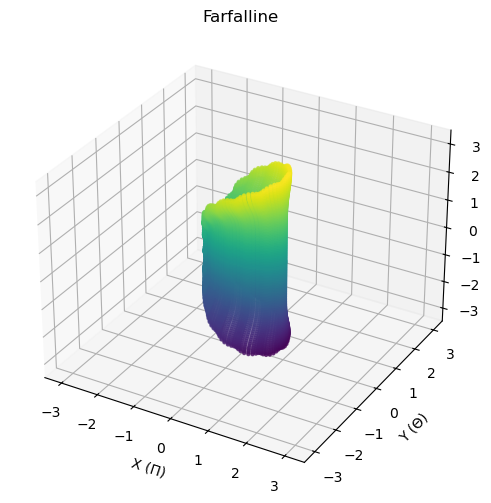

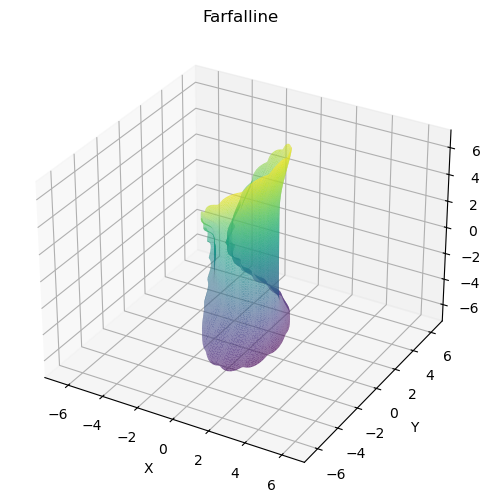

In [ ]:
i_max = 250 
j_max = 50

length = 14 # mm
width = 7 # mm

height = 3 # mm 

thickness = 1 # mm

cooking_time = 6 # minutes

name = "Farfalline"

def alpha(i, j):
    return 30 * np.cos(i / 125 * np.pi) + 0.5 * np.cos(6 * i / 25 * np.pi)

def beta(i, j):
    return 30 * np.sin(i / 125 * np.pi) + 0.5 * np.sin(6 * i / 25 * np.pi)

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return np.cos(3 * alpha(i, j) / 100 * np.pi)

def Θ(i, j):
    return 0.5 * np.sin(3 * alpha(i, j) / 100 * np.pi) * (1 + np.sin(j / 100 * np.pi) ** 10)

def Κ(i, j):
    return beta(i, j) * j / 500

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, height, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=29.99948610869155, Width=43.57063390977709, Height=5.9879228819857175
Scaled dimensions: Length=34.0, Width=50.0, Height=5.999999999999999


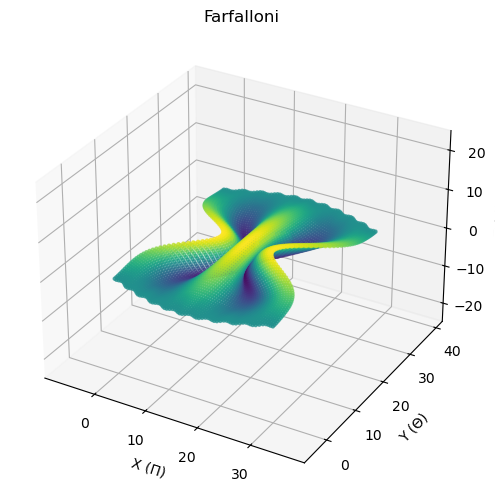

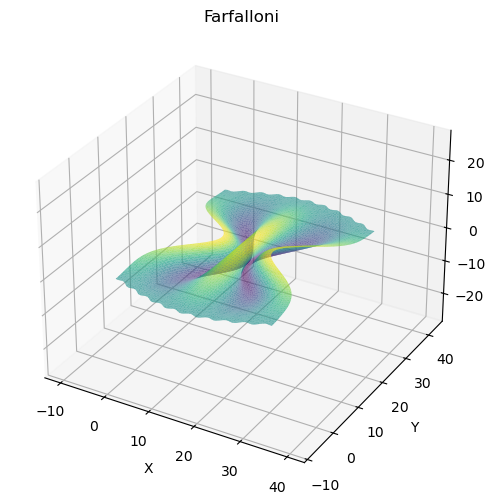

In [ ]:
i_max = 70 
j_max = 70

length = 50 # mm
width = 34 # mm

height = 6 # mm 

cooking_time = 11 # minutes

name = "Farfalloni"

def alpha(i, j):
    return 10 * np.cos((i + 70) / 70 * np.pi) * np.sin((2 * j) / 175 * np.pi + 1.1 * np.pi) ** 9

def beta(i, j):
    return 0.3 * np.sin(6 * j / 7 * np.pi + 0.4 * np.pi)

def gamma(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i <= 52) & (i >= 17)
    mask2 = (i > 52) | (i < 17)
    
    result[mask1] = 7 * np.sin((i[mask1] + 35) / 35 * np.pi) ** 3 * np.sin((2 * j[mask1]) / 175 * np.pi + 1.1 * np.pi) ** 9
    result[mask2] = alpha(i[mask2], j[mask2])
    
    return result

def ι(i, j):
    return j / 2 + 4 * np.sin(i / 70 * np.pi) * np.sin((j - 10) / 100 * np.pi) - 4 * np.sin(i / 70 * np.pi) * np.sin((60 - j) / 100 * np.pi)

def λ(i, j):
    return j / 2 + 4 * np.sin(i / 70 * np.pi) + 0.3 * np.sin((2 * i + 2.8) / 7 * np.pi) * np.sin((j - 60) / 20 * np.pi)

def μ(i, j):
    return j / 2 - 4 * np.sin(i / 70 * np.pi) - 0.3 * np.sin((2 * i + 2.8) / 7 * np.pi) * np.sin((10 - j) / 20 * np.pi)

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 3 * i / 7 + gamma(i, j)

def Θ(i, j):
    result = np.zeros_like(j, dtype=float)
    
    mask1 = (j <= 60) & (j >= 10)
    mask2 = j > 60
    mask3 = j < 10
    
    result[mask1] = ι(i[mask1], j[mask1])
    result[mask2] = λ(i[mask2], j[mask2])
    result[mask3] = μ(i[mask3], j[mask3])
    
    return result

def Κ(i, j):
    return 3 * np.sin((2 * i + 17.5) / 35 * np.pi) * np.sin(j / 70 * np.pi) ** 1.5

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, length, height)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=12.949083244723425, Width=12.561015301032146, Height=54.0
Scaled dimensions: Length=15.000000000000002, Width=15.0, Height=46.0


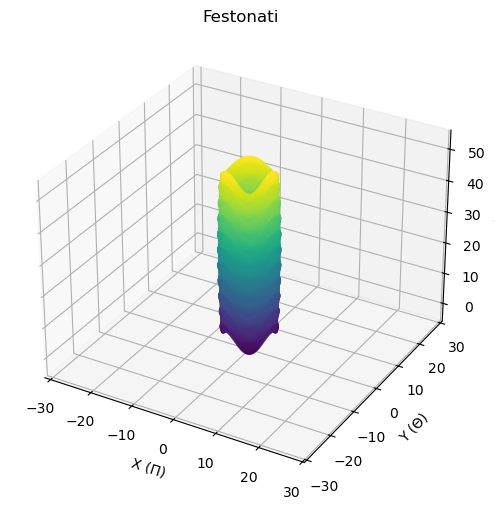

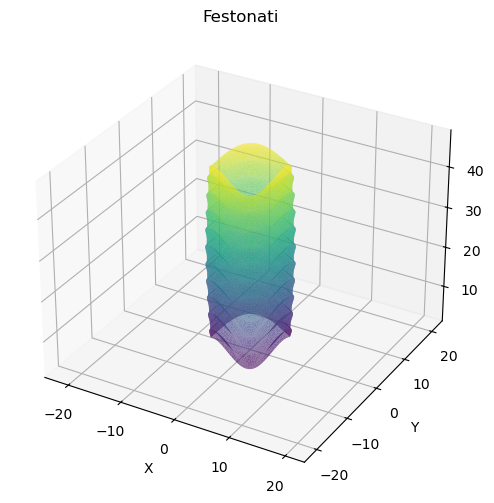

In [10]:
i_max = 100 
j_max = 100

length = 46 # mm
width = 15 # mm

thickness = 1 # mm

cooking_time = 10 # minutes

name = "Festonati"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 5 * np.cos(i / 50 * np.pi) + 0.5 * np.cos(i / 50 * np.pi) * (1 + np.sin(j / 100 * np.pi)) + 0.5 * np.cos((i + 25) / 25 * np.pi) * (1 + np.sin(j / 5 * np.pi))

def Θ(i, j):
    return 5 * np.sin(i / 50 * np.pi) + 0.5 * np.sin(i / 50 * np.pi) * (1 + np.sin(j / 100 * np.pi)) + 0.5 * np.sin(i / 25 * np.pi) * (1 + np.sin(j / 5 * np.pi))

def Κ(i, j):
    return j / 2 + 2 * np.sin((3 * i + 25) / 50 * np.pi)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

In [ ]:
i_max = 150 
j_max = 10

length = 150 # mm
width = 7 # mm

height = 50 # mm 

cooking_time = 3 # minutes

name = "Fettuccine"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 1.8 * np.sin(4 * i / 375 * np.pi)

def Θ(i, j):
    return 1.6 * np.cos(6 * i / 375 * np.pi) * np.sin(3 * i / 375 * np.pi) 

def Κ(i, j):
    return i / 75 + j / 20

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, 0.5*width, width)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))
    
if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

# COME BACK TO THIS ONE

Current dimensions: Length=3.5998420882229167, Width=2.034685379894798, Height=2.5
Scaled dimensions: Length=7.0, Width=3.4999999999999996, Height=6.999999999999999


In [ ]:
i_max = 80 
j_max = 80

length = 33 # mm
width = 23 # mm

height = 5 # mm 

thickness = 1 # mm

cooking_time = 12 # minutes

name = "Fiocchi Rigati"

def alpha(i, j):
    return 10 * np.cos((i + 80) / 80 * np.pi) * np.sin((j + 110) / 100 * np.pi) ** 9

def beta(i, j):
    return 35 * j / 80 + 4 * np.sin(i / 80 * np.pi) * np.sin((j - 10) / 120 * np.pi)

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i <= 60) & (i >= 20)
    mask2 = (i > 60) | (i < 20)
    
    result[mask1] = 30 * i[mask1] / 80 + 7 * np.sin((i[mask1] + 40) / 40 * np.pi) ** 3 * np.sin((j[mask1] + 110) / 100 * np.pi) ** 9
    result[mask2] = 30 * i[mask2] / 80 + alpha(i[mask2], j[mask2])
    
    return result

def Θ(i, j):
    return beta(i, j) - 4 * np.sin(i / 80 * np.pi) * np.sin((70 - j) / 120 * np.pi)

def Κ(i, j):
    return 3 * np.sin((i + 10) / 20 * np.pi) * np.sin(j / 80 * np.pi) ** 1.5 - 0.7 * ((np.sin(3 * j / 8 * np.pi) + 1) / 2) ** 4

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, length, height)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=29.99948610869155, Width=44.797958971132715, Height=6.641298271267118
Scaled dimensions: Length=22.999999999999996, Width=33.0, Height=5.0


In [ ]:
i_max = 70 
j_max = 1000

length = 23 # mm
width = 16 # mm

thickness = 1 # mm

cooking_time = 10 # minutes

name = "Fisarmoniche"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return (1.5 + 3 * (i / 70) ** 5 + 4 * np.sin(j / 200 * np.pi) ** 50) * np.cos(4 * i / 175 * np.pi)

def Θ(i, j):
    return (1.5 + 3 * (i / 70) ** 5+ 4 * np.sin(j / 200 * np.pi) ** 50) * np.sin(4 * i / 175 * np.pi)

def Κ(i, j):
    return j / 50 + np.cos(3 * i / 14 * np.pi) * np.sin(j / 1000 * np.pi)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)
    
# mesh.show()

Current dimensions: Length=11.305909909326656, Width=13.592957538209534, Height=20.0
Scaled dimensions: Length=16.0, Width=16.0, Height=23.0


In [ ]:
i_max = 300 
j_max = 30

length = 8 # mm
width = 7 # mm

thickness = 1 # mm

cooking_time = 6 # minutes

name = "Funghini"

def alpha(i, j):
    return 5 * np.cos(i / 150 * np.pi) + 0.05 * np.cos(i / 3 * np.pi) * np.sin(j / 60 * np.pi) ** 2000

def beta(i, j):
    return j / 30 * (5 * np.sin(i / 150 * np.pi) + 0.05 * np.sin(i / 3 * np.pi))

def gamma(i, j):
    return j / 10 * (2 * np.sin(i / 150 * np.pi) + 0.05 * np.sin(i / 3 * np.pi))

def zeta(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i <= 150)
    mask2 = (i > 150) & (j > 10)
    mask3 = (i > 150) & (j <= 10)
    
    result[mask1] = beta(i[mask1], j[mask1])
    result[mask2] = 2 * np.sin(i[mask2] / 150 * np.pi) + 0.05 * np.sin(i[mask2] / 6 * np.pi)
    result[mask3] = gamma(i[mask3], j[mask3])
    
    return result    

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 0.05 * np.cos(alpha(i, j) / 5 * np.pi) + 0.3 * np.cos(alpha(i, j) / 5 * np.pi) * np.sin(3 * zeta(i, j) / 50 * np.pi) ** 2

def Θ(i, j):
    return 0.01 * np.sin(alpha(i, j) / 5 * np.pi) + 0.3 * np.sin(alpha(i, j) / 5 * np.pi) * np.sin(3 * zeta(i, j) / 50 * np.pi) ** 2

def Κ(i, j):
    return 0.25 * np.sin((zeta(i, j) + 3) / 10 * np.pi)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, length, width, width)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=0.361591754851904, Width=0.35474179358435154, Height=0.17648991869192399
Scaled dimensions: Length=8.0, Width=7.0, Height=7.0


In [ ]:
i_max = 200 
j_max = 25

length = 33 # mm
width = 10 # mm

thickness = 1 # mm

cooking_time = 12 # minutes

name = "Fussili"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 6 * np.cos((3 * i + 10) / 100 * np.pi) * np.cos(j / 25 * np.pi)

def Θ(i, j):
    return 6 * np.sin((3 * i + 10) / 100 * np.pi) * np.cos(j / 25 * np.pi)

def Κ(i, j):
    return 3 * i / 20 + 2.5 * np.cos((j + 12.5) / 25 * np.pi)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, length)

mesh = add_thickness(mesh, thickness)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=12.0, Width=12.0, Height=32.49506682107068
Scaled dimensions: Length=10.0, Width=10.0, Height=33.0


In [ ]:
i_max = 140 
j_max = 40

length = 100 # mm
width = 8 # mm

thickness = 1 # mm

cooking_time = 4 # minutes

name = "Fussili al Ferretto"

def alpha(i, j):
    return 6 * i / 7 + 15 * np.cos(j / 20 * np.pi)

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return (3 + 1.5 * np.sin(i / 140 * np.pi) ** 0.5 * np.sin(j / 20 * np.pi)) * np.sin(13 * i / 280 * np.pi) + 5 * np.sin(2 * alpha(i, j) / 135 * np.pi)

def Θ(i, j):
    return (3 + 1.5 * np.sin(i / 140 * np.pi) ** 0.5 * np.sin(j / 20 * np.pi)) * np.cos(13 * i / 280 * np.pi)

def Κ(i, j):
    return alpha(i, j)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=18.150517341113414, Width=8.938472574072733, Height=150.0
Scaled dimensions: Length=7.999999999999999, Width=8.0, Height=99.99999999999999


In [ ]:
i_max = 150 
j_max = 50

length = 170 # mm
width = 16 # mm

thickness = 1 # mm

cooking_time = 9 # minutes

name = "Fusilli Capri"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 6 * np.cos(j / 50 * np.pi) * np.cos((i + 2.5) / 25 * np.pi)

def Θ(i, j):
    return 6 * np.cos(j / 50 * np.pi) * np.sin((i + 2.5) / 25 * np.pi)

def Κ(i, j):
    return 2 * i / 3 + 14 * np.cos((j + 25) / 50 * np.pi)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=11.976320741139261, Width=12.0, Height=114.0
Scaled dimensions: Length=16.0, Width=16.0, Height=170.0


In [ ]:
i_max = 20 
j_max = 200

length = 210 # mm
width = 27 # mm
diameter = 3 # mm

thickness = 1 # mm

cooking_time = 14 # minutes

name = "Funghini Lunghi Bucati"

def alpha(i, j):
    return 10 + np.cos(i / 10 * np.pi) + 2 * np.cos((j + 10) / 10 * np.pi) + 10 * np.cos((j + 140) / 160 * np.pi)

def beta(i, j):
    return 20 + np.cos(i / 10 * np.pi) + 2 * np.cos((j + 10) / 10 * np.pi)

def gamma(i, j):
    return (j + 10) / 10 * np.pi

def zeta(i, j):
    return i / 10 * np.pi

def eta(i, j):
    return 7 + 20 * np.sin((j - 20) / 160 * np.pi)

def iota(i, j):
    return 70 * (0.1 - (j - 180) / 200)

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    result = np.zeros_like(j, dtype=float)
    
    mask1 = (j <= 180) & (j >= 20)
    mask2 = j > 180
    mask3 = j < 20
    
    result[mask1] = alpha(i[mask1], j[mask1])
    result[mask2] = beta(i[mask2], j[mask2])
    result[mask3] = np.cos(zeta(i[mask3], j[mask3])) + 2 * np.cos(gamma(i[mask3], j[mask3]))
    
    return result    

def Θ(i, j):
    result = np.zeros_like(j, dtype=float)
    
    mask1 = (j <= 180) & (j >= 20)
    mask2 = (j > 180) | (j < 20)
    
    result[mask1] = np.sin(zeta(i[mask1], j[mask1])) + 2 * np.sin(gamma(i[mask1], j[mask1]))
    result[mask2] = np.sin(zeta(i[mask2], j[mask2])) + 2 * np.sin(gamma(i[mask2], j[mask2]))
    
    return result    

def Κ(i, j):
    result = np.zeros_like(j, dtype=float)
    
    mask1 = (j <= 180) & (j >= 20)
    mask2 = j > 180
    mask3 = j < 20
    
    result[mask1] = eta(i[mask1], j[mask1])
    result[mask2] = iota(i[mask2], j[mask2])
    result[mask3] = 7 * j[mask3] / 20
    
    return result    

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, 10*width, 2*width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=26.0, Width=6.0, Height=27.0
Scaled dimensions: Length=270.0, Width=54.0, Height=210.0


In [ ]:
i_max = 140 
j_max = 70

length = 36 # mm
width = 15 # mm
diameter = 8 # mm

thickness = 1 # mm

cooking_time = 9 # minutes

name = "Galletti"

def f(x):
    return ((1 + np.sin((1.5 + x) * np.pi)) / 2) ** 5

def alpha(i, j):
    return 0.4 * np.sin(f(i / 140) * np.pi + 0.5 * np.pi) ** 1000 * np.cos(j / 70 * np.pi)

def beta(i, j):
    return 0.15 * np.sin(f(i / 140) * np.pi + 0.5 * np.pi) ** 1000 * np.cos(j / 7 * np.pi)

def gamma(i, j):
    return 0.4 * np.cos(f(i / 140) * np.pi) ** 1000 * np.sin(j / 70 * np.pi)

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return (0.5 + 0.3 * np.cos(f(i / 140) * 2 * np.pi)) * np.cos(j / 70 * np.pi) + 0.15 * (j / 70) ** 10 * np.cos(f(i / 140) * 2 * np.pi) ** 3 + alpha(i, j)

def Θ(i, j):
    return 0.35 * np.sin(f(i / 140) * 2 * np.pi) + 0.15 * (j / 70) * np.sin(f(i / 140) * 2 * np.pi) + beta(i, j)

def Κ(i, j):
    return (0.4 + 0.3 * np.cos(f(i / 140) * 2 * np.pi)) * np.sin(j / 70 * np.pi) + gamma(i, j)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, length, width, width)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=2.2984236381141825, Width=0.9996331601251546, Height=1.1
Scaled dimensions: Length=36.0, Width=15.0, Height=14.999999999999996


In [ ]:
i_max = 50 
j_max = 150

length = 36 # mm
width = 9 # mm

thickness = 1 # mm

cooking_time = 10 # minutes

name = "Garganelli"

def alpha(i, j):
    return (i - 25) / 125 * j

def beta(i, j):
    return (i - 25) / 125 * (150 - j)

def eta(i, j):
    result = np.zeros_like(j, dtype=float)
    
    mask1 = (j <= 75) & (i <= 25)
    mask2 = (j > 75) & (i <= 25)
    mask3 = (j > 75) & (i > 25)
    mask4 = (j <= 75) & (i > 25)
    
    result[mask1] = alpha(i[mask1], j[mask1])
    result[mask2] = beta(i[mask2], j[mask2])
    result[mask3] = beta(i[mask3], j[mask3])
    result[mask4] = alpha(i[mask4], j[mask4])
    
    return result    

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 0.1 * np.cos(j / 3 * np.pi) + (3 + np.sin(eta(i, j) / 60 * np.pi)) * np.cos(7 * eta(i, j) / 60 * np.pi)

def Θ(i, j):
    return 0.1 * np.sin(j / 3 * np.pi) + (3 + np.sin(eta(i, j) / 60 * np.pi)) * np.sin(7 * eta(i, j) / 60 * np.pi)

def Κ(i, j):
    return 6 * j / 25 + eta(i, j) / 4

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=6.639618625054792, Width=7.023070672243347, Height=36.0
Scaled dimensions: Length=9.0, Width=9.0, Height=36.0


In [ ]:
i_max = 100 
j_max = 50

length = 38 # mm
width = 8 # mm

thickness = 1 # mm

cooking_time = 7 # minutes

name = "Gemelli"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 6 * np.cos(j / 50 * 1.9 * np.pi + 0.55 * np.pi) * np.cos(3 * i / 25)

def Θ(i, j):
    return 6 * np.cos(j / 50 * 1.9 * np.pi + 0.55 * np.pi) * np.sin(3 * i / 25)

def Κ(i, j):
    return 8 * np.sin(j / 50 * 1.9 * np.pi + 0.55 * np.pi) + 3 * i / 4

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)
    
# mesh.show()

Current dimensions: Length=11.997868228569708, Width=11.997168995568451, Height=90.9015067247611
Scaled dimensions: Length=8.0, Width=8.0, Height=38.0


In [ ]:
i_max = 150 
j_max = 40

length = 29 # mm
width = 10 # mm

thickness = 1 # mm

cooking_time = 6 # minutes (5-7 minutes in the book)

name = "Gigli"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return (0.8 - 0.6 * np.sin(j / 80 * np.pi) ** 0.5) * np.cos(i / 50 * np.pi) + 0.08 * np.sin(j / 40 * np.pi)

def Θ(i, j):
    return (0.8 - 0.6 * np.sin(j / 80 * np.pi) ** 0.5) * np.sin(i / 50 * np.pi) + 0.08 * np.sin(j / 40 * np.pi)

def Κ(i, j):
    return 1.1 * j / 40 + 0.7 * (1 - np.sin((150 - i) / 300) * np.pi) ** 2

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, width)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=1.6, Width=1.6, Height=1.7999976681979504
Scaled dimensions: Length=10.0, Width=10.0, Height=9.999999999999998


In [ ]:
i_max = 150 
j_max = 40

length = 30 # mm
width = 15 # mm

thickness = 1 # mm

cooking_time = 7.5 # minutes (7-8 minutes in the book)

name = "Giglio Ondulato"

def alpha(i, j):
    return 0.6 + 0.03 * ((40 - j) / 40) ** 10 * np.cos((4 * i + 75) / 15 * np.pi) - 0.5 * np.sin(j / 80 * np.pi) ** 0.6

def beta(i, j):
    return np.sin(2 * i / 75 * np.pi) + (i / 150) ** 10 * (0.08 * np.sin(j / 40 * np.pi) + 0.03 * np.sin(j / 5 * np.pi))

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return alpha(i, j) * np.cos(2 * i / 75 * np.pi) + (i / 150) ** 10 * (0.08 * np.sin(j / 40 * np.pi) + 0.03 * np.cos(j / 5 * np.pi))

def Θ(i, j):
    return (0.6 + 0.03 * ((40 - j) / 40) ** 10 * np.sin(4 * i / 15 * np.pi) - 0.5 * np.sin(j / 80 * np.pi) ** 0.6) * beta(i, j)

def Κ(i, j):
    return 1.1 * j / 40 + 0.7 * (1 - np.sin((150 - i) / 300  * np.pi))

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=1.2316537688871592, Width=1.245630563647433, Height=1.8
Scaled dimensions: Length=15.0, Width=15.0, Height=30.000000000000004


In [ ]:
i_max = 50 
j_max = 150

length = 22 # mm
width = 6 # mm

cooking_time = 12 # minutes

name = "Gnocchetti Sardi"

def alpha(i, j):
    return 0.8 + 3 * np.sin(j / 150 * np.pi) ** 0.8

def beta(i, j):
    return np.abs(np.cos((2 * j + 7.5) / 15 * np.pi))

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return alpha(i, j) * np.cos(i / 50 * np.pi) + 0.2 * np.cos(i / 50 * np.pi) * np.sin(j / 150 * np.pi) * beta(i, j)

def Θ(i, j):
    return alpha(i, j) * np.sin(i / 50 * np.pi) + 0.2 * np.sin(i / 50 * np.pi) * np.sin(j / 150 * np.pi) * beta(i, j)

def Κ(i, j):
    return 13 * np.cos(j / 150 * np.pi)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)
    
# mesh.show()

Current dimensions: Length=7.979573398922431, Width=3.9897866994612157, Height=26.0
Scaled dimensions: Length=6.0, Width=6.0, Height=22.0


In [ ]:
i_max = 40 
j_max = 130

length = 32 # mm
width = 16 # mm

thickness = 1 # mm

cooking_time = 10 # minutes

name = "Gnocchi"

def alpha(i, j):
    return i / 40 * np.sin(j / 130 * np.pi)

def beta(i, j):
    return np.abs(np.cos((j + 13) / 26 * np.pi))

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 0.2 * np.cos(i / 40 * 1.3 * np.pi) * np.sin(j / 130 * np.pi) * beta(i, j) + alpha(i, j) * np.cos(i / 40 * 1.3 * np.pi)

def Θ(i, j):
    return 0.2 * np.sin(i / 40 * 1.3 * np.pi) * np.sin(j / 130 * np.pi) * beta(i, j) + alpha(i, j) * np.sin(i / 40 * 1.3 * np.pi)

def Κ(i, j):
    return 1.5 * np.cos(j / 130 * np.pi)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, length)

mesh = add_thickness(mesh, thickness)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=1.284880122742854, Width=1.6003517338715254, Height=3.0
Scaled dimensions: Length=16.0, Width=16.0, Height=32.0


In [ ]:
i_max = 25 
j_max = 150

length = 26 # mm
width = 13 # mm
diameter = 3 # mm

thickness = 1 # mm

cooking_time = 9 # minutes

name = "Graminga"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return (0.5 + 5.6 * (j / 150) ** 2 + 0.3 * np.cos(2 * i / 25 * np.pi)) * np.cos(2.1 * j / 150 * np.pi)

def Θ(i, j):
    return 0.3 * np.sin(2 * i / 25 * np.pi)

def Κ(i, j):
    return (0.5 + 3.2 * (j / 150) ** 2 + 0.3 * np.cos(2 * i / 25 * np.pi)) * np.sin(2.1 * j / 150 * np.pi)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, length, diameter, width)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=8.320965188758045, Width=0.598816037056963, Height=3.7657782517614393
Scaled dimensions: Length=26.0, Width=3.0, Height=13.0


In [ ]:
i_max = 50 
j_max = 90

length = 15 # mm
width = 5 # mm

height = 3 # mm 

thickness = 1 # mm

cooking_time = 6 # minutes

name = "Lancette"

def alpha(i, j):
    return 0.4 * np.sin(5 * j / 9 * np.pi)

def beta(i, j):
    return np.sin((j + 45) / 90 * np.pi)

def gamma(i, j):
    return (3 * i - 75) / 5 * np.sin(j / 90 * np.pi) - (1 - np.sin(i / 50 * np.pi)) ** 25 * alpha(i, j) * beta(i , j)

def zeta(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i <= 25)
    mask2 = (i > 25)
    
    result[mask1] = gamma(i[mask1], j[mask1])
    result[mask2] = 30 * (i[mask2] - 25) / 50 * np.sin(j[mask2] / 90 * np.pi) + np.sin((i[mask2] - 25) / 50 * np.pi) * alpha(i[mask2], j[mask2]) * beta(i[mask2], j[mask2])

    return result   

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 4 * np.cos(3 * zeta(i, j) / 50 * np.pi)

def Θ(i, j):
    return 4 * np.sin(3 * zeta(i, j) / 50 * np.pi) * (0.3 + (1 - np.sin(j / 90 * np.pi)) ** 0.6)

def Κ(i, j):
    return j / 3

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, height, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)
    
# mesh.show()

Current dimensions: Length=7.8052987566293055, Width=7.7163985733446445, Height=30.0
Scaled dimensions: Length=3.0, Width=5.0, Height=15.0


In [ ]:
i_max = 50 
j_max = 150

length = 170 # mm
width = 75 # mm

thickness = 5 # mm

cooking_time = 24 # minutes

name = "Lasagna Larga Doppia Riccia"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i <= 42) & (i >= 8)
    mask2 = (i > 42)
    mask3 = (i < 8)
    
    result[mask1] = 5 / 6 + (5 * i[mask1] - 40) / 34
    result[mask2] = 5 / 6 * (7 + (i[mask2] - 42) / 8)
    result[mask3] = 5 * i[mask3] / 48

    return result    

def Θ(i, j):
    return j / 15

def Κ(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i <= 42) & (i >= 8)
    mask2 = (i > 42)
    mask3 = (i < 8)
    
    result[mask1] = 0
    result[mask2] = 0.25 * (i[mask2] - 42) / 8 * np.cos((j[mask2] + 9) / 6 * np.pi)
    result[mask3] = (8 - i[mask3]) / 32 * np.cos((j[mask3] + 3) / 6 * np.pi)

    return result    

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, length, thickness)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=6.666666666666667, Width=10.0, Height=0.5
Scaled dimensions: Length=75.0, Width=170.0, Height=5.0


In [ ]:
i_max = 150 
j_max = 50

length = 255 # mm
width = 3 # mm

thickness = 1 # mm

cooking_time = 11 # minutes

name = "Linguine"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return np.cos(i / 75 * np.pi)    

def Θ(i, j):
    return 2 * np.sin(i / 75 * np.pi)

def Κ(i, j):
    return j / 5

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, 2*width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=2.0, Width=3.999122733899382, Height=10.0
Scaled dimensions: Length=3.0, Width=6.0, Height=255.0


In [ ]:
i_max = 240 
j_max = 60

length = 47 # mm
width = 38 # mm

height = 25 # mm 

thickness = 1 # mm

cooking_time = 13 # minutes

name = "Lumaconi Rigati"

def alpha(i, j):
    return 0.45 + 0.01 * np.cos(i / 3 * np.pi) + j / 300 * np.abs(np.cos(i / 240 * np.pi)) * np.cos(i / 120 * np.pi) ** 20

def beta(i, j):
    return j / 300 * np.abs(np.cos(i / 240 * np.pi)) * np.sin(i / 120 * np.pi) + 0.125 * (j / 60) ** 6 * np.sin(i / 120 * np.pi)

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return (0.4 * np.cos(i / 120 * np.pi) + alpha(i, j)) * np.cos(j / 60 * np.pi) + 0.48 * (j / 60) ** 6 * np.sin((i + 60) / 120 * np.pi) ** 3

def Θ(i, j):
    return 0.5 * np.sin(i / 120 * np.pi) + 0.01 * np.sin(i / 3 * np.pi) + beta(i, j)

def Κ(i, j):
    return (0.45 + 0.4 * np.cos(i / 120 * np.pi)) * np.sin(j / 60 * np.pi)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, length, width, height)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=1.6027458039206548, Width=1.5561023974327917, Height=0.8500000000000001
Scaled dimensions: Length=47.0, Width=38.0, Height=25.0


In [ ]:
i_max = 150 
j_max = 50

length = 40 # mm
diameter = 8 # mm

thickness = 1 # mm

cooking_time = 12 # minutes

name = "Maccheroni"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 8 * np.cos(i / 75 * np.pi) + 0.2 * np.cos(4 * i / 15 * np.pi) + 5 * np.cos(j / 100 * np.pi)

def Θ(i, j):
    return 8 * np.sin(i / 75 * np.pi) + 0.2 * np.sin(4 * i / 15 * np.pi) + 4 * np.sin(j / 100 * np.pi)

def Κ(i, j):
    return 6 * j / 5

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, diameter, diameter, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=21.29872100939081, Width=20.34885026137041, Height=60.0
Scaled dimensions: Length=8.0, Width=8.0, Height=40.0


In [ ]:
i_max = 120 
j_max = 60

length = 258 # mm
width = 2 # mm

thickness = 0.5 # mm

cooking_time = 11 # minutes

name = "Maccheroni Alla Chitarra"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 0.05 * np.cos(i / 60 * np.pi) ** 3 + 0.05 * np.cos(i / 60 * np.pi)

def Θ(i, j):
    return 0.05 * np.sin(i / 60 * np.pi) ** 3 + 0.05 * np.sin(i / 60 * np.pi)

def Κ(i, j):
    return j / 60

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=0.2, Width=0.2, Height=1.0
Scaled dimensions: Length=2.0, Width=2.0, Height=258.0


In [ ]:
i_max = 30 
j_max = 150

length = 240 # mm
width = 13 # mm

height = 10 # mm 

thickness = 1 # mm

cooking_time = 9 # minutes

name = "Mafaldine"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 7 * i / 18

def Θ(i, j):
    return j / 3

def Κ(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i <= 24) & (i >= 6)
    mask2 = (i > 24)
    mask3 = (i < 6)
    
    result[mask1] = 0
    result[mask2] = (i[mask2] - 24) / 6 * np.cos((j[mask2] + 15) / 10 * np.pi)
    result[mask3] = (6 - i[mask3]) / 6 * np.cos((j[mask3] + 5) / 10 * np.pi)

    return result    

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, length, height)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=11.666666666666666, Width=50.0, Height=2.0
Scaled dimensions: Length=13.0, Width=240.0, Height=10.0


In [ ]:
i_max = 200 
j_max = 40

length = 130 # mm
width = 35 # mm

thickness = 1 # mm

cooking_time = 8 # minutes

name = "Manicotti"

def alpha(i, j):
    return - 7 * np.sin((i - 100) / 100 * np.pi) ** 2 + 0.3 * np.sin((3 * i - 300) / 10 * np.pi)

def beta(i, j):
    return - 8 * np.cos((i - 100) / 100 * np.pi) + 0.3 * np.cos((3 * i - 300) / 10 * np.pi)

def gamma(i, j):
    return - 8 * np.cos((i - 100) / 100 * np.pi) + 22 * np.sin((j - 20) / 40 * np.pi)

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i < 100)
    mask2 = (i >= 100)
    
    result[mask1] = 7 * np.sin(i[mask1] / 100 * np.pi) ** 2 + 0.3 * np.sin(3 * i[mask1] / 10 * np.pi)
    result[mask2] = alpha(i[mask2], j[mask2])

    return result    

def Θ(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i < 100)
    mask2 = (i >= 100)
    
    result[mask1] = 8 * np.cos(i[mask1] / 100 * np.pi) + 0.3 * np.cos(3 * i[mask1] / 10 * np.pi)
    result[mask2] = beta(i[mask2], j[mask2])

    return result    

def Κ(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i < 100)
    mask2 = (i >= 100)
    
    result[mask1] = 8 * np.cos(i[mask1] / 100 * np.pi) + 22 * np.sin((j[mask1] - 20) / 40 * np.pi)
    result[mask2] = gamma(i[mask2], j[mask2])

    return result       

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, 0.6*width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=14.515436818978436, Width=16.549812671713187, Height=60.0
Scaled dimensions: Length=21.0, Width=35.0, Height=130.0


In [ ]:
i_max = 150 
j_max = 15

width = 7 # mm
diameter = 20 # mm

thickness = 1 # mm

cooking_time = 11 # minutes

name = "Orecchiette"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 2 * j / 3 * np.cos(i / 75 * np.pi) + 0.3 * np.cos(2 * i / 15 * np.pi)

def Θ(i, j):
    return 10 * np.sin(i / 75 * np.pi)

def Κ(i, j):
    return 0.1 * np.cos(i / 3 * np.pi) + 5 * (0.5 + 0.5 * np.cos(2 * i / 75 * np.pi)) ** 4 * np.cos(j / 30 * np.pi) ** 2 + 1.5 * (0.5 + 0.5 * np.cos(2 * i / 75 * np.pi)) ** 5 * np.sin(j / 30 * np.pi) ** 10

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, diameter, diameter, width)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=20.23147600733806, Width=19.99561366949691, Height=5.199999999998571
Scaled dimensions: Length=20.0, Width=20.0, Height=6.999999999999999


In [ ]:
i_max = 150 
j_max = 30

length = 46 # mm
width = 29 # mm

thickness = 1 # mm

cooking_time = 12 # minutes

name = "Paccheri"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return (j + 60) / 60 * np.cos(i / 75 * np.pi) + 0.5 * np.cos(j / 60 * np.pi) + np.cos((i + j) / 75 * np.pi)

def Θ(i, j):
    return 2.6 * np.sin(i / 75 * np.pi) + 0.3 * np.sin(j / 60 * np.pi)

def Κ(i, j):
    return 7 * j / 30

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=4.604076314274145, Width=5.498859554069196, Height=7.0
Scaled dimensions: Length=29.0, Width=29.0, Height=46.0


In [ ]:
i_max = 800 
j_max = 5

width = 18 # mm
diameter = 50 # mm

thickness = 1 # mm

cooking_time = 7 # minutes

name = "Papardelle"

def Τ(i, j):
    return 0.6 * (np.cos(i / 80 * np.pi) + 3 * j / 50 * np.sin(21 * i / 800 * np.pi))

def Χ(i, j):
    return 0.8 * (np.sin(i / 3200 * np.pi) ** 0.5 * np.sin(i / 80 * np.pi))

def Ψ(i, j):
    return 0.9 * (3 * j / 50 + 0.5 * np.sin(i / 200 * np.pi))

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return np.cos(i / 80 * np.pi) + 3 * j / 50 * np.sin(21 * i / 800 * np.pi)

def Θ(i, j):
    return np.sin(i / 3200 * np.pi) ** 0.1 * np.sin(i / 80 * np.pi)

def Κ(i, j):
    return 3 * j / 50 + 0.5 * np.sin(i / 200 * np.pi)

mesh1 = pasta_creator(Π, Θ, Κ, i_max, j_max)
mesh2 = pasta_creator(Τ, Χ, Ψ, i_max, j_max)

combined_mesh = trimesh.util.concatenate([mesh1, mesh2])

mesh = scale_mesh_to_dimensions(combined_mesh, diameter, diameter, width)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=2.372300632447849, Width=1.9151797497107907, Height=1.3
Scaled dimensions: Length=49.99999999999999, Width=50.0, Height=18.0


In [ ]:
i_max = 170 
j_max = 40

length = 55 # mm
diameter = 8 # mm

cooking_time = 13 # minutes

name = "Penne Rigate"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i < 85)
    mask2 = (i >= 85)
    
    result[mask1] = 4 * np.sin(i[mask1] / 85 * np.pi) ** 2 + 0.1 * np.sin(6 * i[mask1] / 17 * np.pi)
    result[mask2] = - 4 * np.sin((i[mask2] - 85) / 85 * np.pi) ** 2 + 0.1 * np.sin(6 * (i[mask2] - 85) / 17 * np.pi)

    return result 

def Θ(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i < 85)
    mask2 = (i >= 85)
    
    result[mask1] = 4 * np.cos(i[mask1] / 85 * np.pi) + 0.1 * np.cos(6 * i[mask1] / 17 * np.pi)
    result[mask2] = - 4 * np.cos((i[mask2] - 85) / 85 * np.pi) + 0.1 * np.cos(6 * (i[mask2] - 85) / 17 * np.pi)

    return result 

def Κ(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i < 85)
    mask2 = (i >= 85)
    
    result[mask1] = 7 * np.cos(i[mask1] / 85 * np.pi) + 15 * np.sin((j[mask1] - 20) / 40 * np.pi)
    result[mask2] = - 7 * np.cos((i[mask2] - 85) / 85 * np.pi) + 15 * np.sin((j[mask2] - 20) / 40 * np.pi)

    return result 

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, diameter, diameter, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=8.174583382840101, Width=8.173733857549486, Height=44.0
Scaled dimensions: Length=8.0, Width=7.999999999999999, Height=55.0


In [ ]:
i_max = 200 
j_max = 40

length = 75 # mm
width = 28 # mm

thickness = 1 # mm

cooking_time = 10 # minutes

name = "Pennoni Lisci"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i < 100)
    mask2 = (i >= 100)
    
    result[mask1] = 7 * np.sin(i[mask1] / 100 * np.pi) ** 2
    result[mask2] = - 7 * np.sin((i[mask2] - 100) / 100 * np.pi) ** 2

    return result 

def Θ(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i < 100)
    mask2 = (i >= 100)

    result[mask1] = 8 * np.cos(i[mask1] / 100 * np.pi)
    result[mask2] = - 8 * np.cos((i[mask2] - 100) / 100 * np.pi)

    return result 

def Κ(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i < 100)
    mask2 = (i >= 100)
    
    result[mask1] = 12 * np.cos(i[mask1] / 100 * np.pi) + 15 * np.sin((j[mask1] - 20) / 40 * np.pi)
    result[mask2] = - 12 * np.cos((i[mask2] - 100) / 100 * np.pi) + 15 * np.sin((j[mask2] - 20) / 40 * np.pi)

    return result 

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=14.0, Width=16.0, Height=54.0
Scaled dimensions: Length=28.0, Width=28.0, Height=75.0


In [ ]:
i_max = 200 
j_max = 40

length = 84 # mm
width = 28 # mm

thickness = 1 # mm

cooking_time = 13 # minutes

name = "Pennoni Rigati"

def alpha(i, j):
    return - 7 * np.sin((i - 100) / 100 * np.pi) ** 2 + 0.2 * np.sin((3 * i - 300) / 10 * np.pi)

def beta(i, j):
    return - 8 * np.cos((i - 100) / 100 * np.pi) + 0.2 * np.cos((3 * i - 300) / 10 * np.pi)

def gamma(i, j):
    return - 12 * np.cos((i - 100) / 100 * np.pi) + 15 * np.sin((j - 20) / 40 * np.pi)

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i < 100)
    mask2 = (i >= 100)
    
    result[mask1] = 7 * np.sin(i[mask1] / 100 * np.pi) ** 2 + 0.15 * np.sin(3 * i[mask1] / 10 * np.pi)
    result[mask2] = alpha(i[mask2], j[mask2])

    return result 

def Θ(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i < 100)
    mask2 = (i >= 100)

    result[mask1] = 8 * np.cos(i[mask1] / 100 * np.pi) + 0.15 * np.cos(3 * i[mask1] / 10 * np.pi)
    result[mask2] = beta(i[mask2], j[mask2])

    return result 

def Κ(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i < 100)
    mask2 = (i >= 100)
    
    result[mask1] = 12 * np.cos(i[mask1] / 100 * np.pi) + 15 * np.sin((j[mask1] - 20) / 40 * np.pi)
    result[mask2] = gamma(i[mask2], j[mask2])

    return result 

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)
    
# mesh.show()

Current dimensions: Length=14.277672689904648, Width=16.35470702008367, Height=54.0
Scaled dimensions: Length=28.0, Width=28.0, Height=84.0


In [ ]:
i_max = 80 
j_max = 80

length = 9 # mm
width = 3 # mm

thickness = 1 # mm

cooking_time = 11 # minutes

name = "Puntalette"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 1.4 * np.sin(j / 80 * np.pi) ** 1.2 * np.cos(i / 40 * np.pi)

def Θ(i, j):
    return 2.5 * np.sin(j / 80 * np.pi) ** 1.2 * np.sin(i / 40 * np.pi)

def Κ(i, j):
    return 8 * np.cos(j / 80 * np.pi)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=2.8, Width=5.0, Height=16.0
Scaled dimensions: Length=2.9999999999999996, Width=3.0, Height=9.0


In [ ]:
i_max = 500 
j_max = 50

diameter = 15 # mm
height = 35 # mm (given as thickness in the book)

thickness = 1 # mm

cooking_time = 15 # minutes

name = "Quadrefiore"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 2 * np.cos(i / 250 * np.pi) * (np.abs(np.sin(3 * i / 250 * np.pi))) ** 20 + (0.6 + 0.9 * np.sin(j / 50 * np.pi)) * np.cos(i / 250 * np.pi) + 0.2 * np.cos(4 * j / 25 * np.pi)

def Θ(i, j):
    return 2 * np.sin(i / 250 * np.pi) * (np.abs(np.sin(3 * i / 250 * np.pi))) ** 20 + (0.6 + 0.9 * np.sin(j / 50 * np.pi)) * np.sin(i / 250 * np.pi) + 1.5 * np.sin(j / 50 * np.pi)

def Κ(i, j):
    return 3 * j / 10

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, diameter, diameter, height)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=6.412793364298521, Width=7.6, Height=15.0
Scaled dimensions: Length=15.0, Width=15.000000000000002, Height=35.0


In [ ]:
i_max = 70 
j_max = 70

length = 6 # mm
width = 6 # mm

thickness = 0.5 # mm

cooking_time = 6 # minutes

name = "Quadretti"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 3 * i / 14

def Θ(i, j):
    return 3 * j / 14

def Κ(i, j):
    return np.zeros_like(i, dtype=float)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, length, width, thickness)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)
    
# mesh.show()

Current dimensions: Length=15.0, Width=15.0, Height=0.0
Scaled dimensions: Length=6.0, Width=6.0, Height=0.0


In [ ]:
i_max = 3000 
j_max = 4

length = 31 # mm
width = 30 # mm #15 mm

height = 4 # mm 

thickness = 0.5 # mm

cooking_time = 11 # minutes

name = "Rachette"

def alpha(i, j):
    return np.sin(i / 2000 * np.pi) ** 0.5

def Τ(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i <= 2000)
    mask2 = (i > 2000)
    
    result[mask1] = 2.1 * np.cos((2 * alpha(i[mask1], j[mask1]) + 1) * np.pi) + 0.65 * np.cos((2 * alpha(i[mask1], j[mask1]) + 0.5) * np.pi) + 2.5 * np.sin((alpha(i[mask1], j[mask1]) + 1.83) * np.pi) ** 500
    result[mask2] = - 2.1

    return result

def Χ(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i <= 2000)
    mask2 = (i > 2000)
    
    result[mask1] = 2.5 * np.sin((2 * alpha(i[mask1], j[mask1]) + 1) * np.pi) + 0.1 * np.sin(2 * alpha(i[mask1], j[mask1]) * np.pi) + 3 * np.sin((alpha(i[mask1], j[mask1]) + 1.83) * np.pi) ** 500
    result[mask2] = 0

    return result 

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 2 * np.cos((i + 1500) / 1500 * np.pi) + 0.65 * np.cos((i + 750) / 1500 * np.pi) + 2 * np.abs(np.cos(i / 300 * np.pi)) ** 100 * np.cos(i / 1500 * np.pi)

def Θ(i, j):
    return 2.4 * np.sin((i + 1500) / 1500 * np.pi) + 0.1 * np.sin(i / 1500 * np.pi) + 2.3 * np.abs(np.sin(i / 300 * np.pi)) ** 100 * np.sin(i / 1500 * np.pi)

def Κ(i, j):
    return j / 4

mesh1 = pasta_creator(Π, Θ, Κ, i_max, j_max)
mesh2 = pasta_creator(Τ, Χ, Κ, i_max, j_max)

combined_mesh = trimesh.util.concatenate([mesh1, mesh2])

mesh = scale_mesh_to_dimensions(combined_mesh, width, length, height)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=6.279481005307608, Width=7.504670423659004, Height=1.0
Scaled dimensions: Length=30.0, Width=31.0, Height=4.0


In [ ]:
i_max = 70 
j_max = 1000

length = 24 # mm
width = 17 # mm

thickness = 1 # mm

cooking_time = 9 # minutes

name = "Radiatori"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return (1.5 + 3 * (i / 70) ** 5 + 4 * np.sin(j / 200 * np.pi) ** 50) * np.cos(4 * i / 175 * np.pi)

def Θ(i, j):
    return (1.5 + 3 * (i / 70) ** 5 + 4 * np.sin(j / 200 * np.pi) ** 50) * np.sin(4 * i / 175 * np.pi)

def Κ(i, j):
    return j / 50 + np.cos(3 * i / 14 * np.pi) * np.sin(j / 1000 * np.pi)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=11.305909909326656, Width=13.592957538209534, Height=20.0
Scaled dimensions: Length=17.0, Width=17.0, Height=24.0


In [ ]:
i_max = 100 
j_max = 100

length = 50 # mm
width = 50 # mm

height = 4 # mm 

thickness = 1 # mm

cooking_time = 5 # minutes

name = "Ravioli Quadrati"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return i / 2 + 0.4 * np.sin((j + 2.5) / 5 * np.pi) * (np.sin(i / 200 * np.pi) ** 0.2 - np.cos(i / 200 * np.pi) ** 0.2)

def Θ(i, j):
    return j / 2 + 0.4 * np.sin((11 * i + 25) / 50 * np.pi) * (np.sin(j / 200 * np.pi) ** 0.2 - np.cos(j / 200 * np.pi) ** 0.2)

def Κ(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i < 90) & (i > 10) & (j < 90) & (j > 10)
    mask2 = ((i >= 90) | (i <= 10) | (j >= 90) | (j <= 10))
    
    result[mask1] = 10 * np.sin((i[mask1] - 10) / 80 * np.pi) ** 0.6 * np.sin((j[mask1] - 10) / 80 * np.pi) ** 0.6
    result[mask2] = 0

    return result 

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, length, height)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=50.79977119992497, Width=50.79977119992497, Height=10.0
Scaled dimensions: Length=50.0, Width=50.0, Height=4.0


In [ ]:
i_max = 80 
j_max = 80

length = 50 # mm
width = 50 # mm

height = 10 # mm 

thickness = 1 # mm

cooking_time = 5 # minutes

name = "Ravioli Tondi"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 5 * i / 8 + 0.5 * np.sin((j + 2) / 4 * np.pi) * (np.sin(i / 160 * np.pi) ** 0.2 - np.cos(i / 160 * np.pi) ** 0.2)

def Θ(i, j):
    return 5 * j / 8 + 0.5 * np.sin((i + 2) / 4 * np.pi) * (np.sin(j / 160 * np.pi) ** 0.2 - np.cos(j / 160 * np.pi) ** 0.2)

def Κ(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i - 40) ** 2 + (j - 40) ** 2 <= 600
    mask2 = (i - 40) ** 2 + (j - 40) ** 2 > 600
    
    result[mask1] = 0.5 * np.sqrt(600 - (i[mask1] - 40) ** 2 - (j[mask1] - 40) ** 2)
    result[mask2] = 0

    return result

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, length, height)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=50.99971399990621, Width=50.99971399990621, Height=12.24744871391589
Scaled dimensions: Length=50.0, Width=50.0, Height=10.0


In [ ]:
i_max = 50 
j_max = 200

length = 35 # mm
width = 15 # mm

thickness = 1 # mm

cooking_time = 11 # minutes

name = "Riccoli"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return (2 + 8 * np.sin(i / 100 * np.pi) + 9 * np.sin((11 * j + 100) / 400 * np.pi) ** 2) * np.cos(4 * i / 125 * np.pi)

def Θ(i, j):
    return (2 + 8 * np.sin(i / 100 * np.pi) + 9 * np.sin((11 * j + 100) / 400 * np.pi) ** 2) * np.sin(4 * i / 125 * np.pi)

def Κ(i, j):
    return j / 4

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=28.973693639865054, Width=33.89045616523492, Height=50.0
Scaled dimensions: Length=15.0, Width=15.0, Height=35.0


In [ ]:
i_max = 20 
j_max = 100

length = 36 # mm
width = 8 # mm

thickness = 1 # mm

cooking_time = 4.5 # minutes (given as 4-5 minutes in the book)

name = "Riccoli Ai Cinque Sapori"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 1.5 * np.cos(i / 20 * np.pi) * (1 + 0.5 * np.sin(j / 25 * np.pi) * np.sin(i / 40 * np.pi) + 0.43 * np.sin((j + 18.75) / 25 * np.pi) * np.cos(i / 40 * np.pi)) + 2 * np.cos(j / 50 * np.pi)

def Θ(i, j):
    return 1.5 * np.sin(i / 20 * np.pi) ** 3 + np.cos(j / 25 * np.pi)

def Κ(i, j):
    return np.sin(j / 100 * np.pi) + 20 * np.cos(j / 200 * np.pi) ** 2

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, 2*width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=7.944094786532771, Width=3.5, Height=20.049727959349315
Scaled dimensions: Length=15.999999999999998, Width=8.0, Height=36.0


In [ ]:
i_max = 240 
j_max = 60

length = 40 # mm
width = 16 # mm

thickness = 1 # mm

cooking_time = 13 # minutes

name = "Rigatoni"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 0.2 * np.sin((7 * i + 15) / 30 * np.pi) + 2 * np.cos((j + 60) / 120 * np.pi) + (7 + (60 - j) / 60 * np.sin(i / 240 * np.pi)) * np.cos(i / 120 * np.pi)

def Θ(i, j):
    return 0.2 * np.sin(7 * i / 30 * np.pi) + (8 + 0.1 * (60 - j) / 60 + j / 30 * np.cos(i / 240 * np.pi)) * np.sin(i / 120 * np.pi)

def Κ(i, j):
    return j / 2

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=16.458027607849953, Width=17.881609851290115, Height=30.0
Scaled dimensions: Length=16.0, Width=15.999999999999998, Height=40.0


In [ ]:
i_max = 50 
j_max = 50

length = 46 # mm
width = 24 # mm

height = 6 # mm 

thickness = 1 # mm

cooking_time = 12 # minutes

name = "Rombi"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i >= 13) & (i <= 37)
    mask2 = i < 13
    mask3 = i > 37
    
    result[mask1] = i[mask1] / 20 + j[mask1] / 25 - 1 / 20
    result[mask2] = 3 * i[mask2] / 65 + j[mask2] / 25
    result[mask3] = 6 / 65 + 3 * i[mask3] / 65 + j[mask3] / 25

    return result

def Θ(i, j):
    return j / 25

def Κ(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i >= 13) & (i <= 37)
    mask2 = i < 13
    mask3 = i > 37
    
    result[mask1] = 0
    result[mask2] = 0.2 * (13 - i[mask2]) / 13 * np.cos((2 * j[mask2] + 12.5) / 25 * np.pi)
    result[mask3] = (i[mask3] - 37) / 65 * np.cos((2 * j[mask3] + 37.5) / 25 * np.pi)

    return result

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, length, width, height)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=4.4, Width=2.0, Height=0.3992106913713087
Scaled dimensions: Length=46.0, Width=24.0, Height=6.0


In [ ]:
i_max = 2000 
j_max = 5

diameter = 21 # mm
height = 6 # mm (given as depth in the book)

thickness = 0.1 # mm

cooking_time = 12 # minutes

name = "Rotelle"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 0.5 * np.cos(i / 1000 * np.pi) + 1.5 * (np.abs(np.sin(3 * i / 1000 * np.pi))) ** 50 * np.cos(i / 1000 * np.pi)

def Θ(i, j):
    return 0.5 * np.sin(i / 1000 * np.pi) + 1.5 * (np.abs(np.sin(3 * i / 1000 * np.pi))) ** 50 * np.sin(i / 1000 * np.pi)

def Τ(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i <= 666)
    mask2 = (i > 666)
    
    result[mask1] = 2 * np.cos(3 * i[mask1] / 1000 * np.pi) + 0.03 * np.cos(93 * i[mask1] / 1000 * np.pi)
    result[mask2] = 2.03

    return result

def Χ(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i <= 666)
    mask2 = (i > 666)

    result[mask1] = 2.05 * np.sin(3 * i[mask1] / 1000 * np.pi) + 0.03 * np.sin(93 * i[mask1] / 1000 * np.pi)
    result[mask2] = 0

    return result

def Κ(i, j):
    return j / 5

mesh1 = pasta_creator(Π, Θ, Κ, i_max, j_max)
mesh2 = pasta_creator(Τ, Χ, Κ, i_max, j_max)

combined_mesh = trimesh.util.concatenate([mesh1, mesh2])

mesh = scale_mesh_to_dimensions(combined_mesh, diameter, diameter, height)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)
    
# mesh.show()

Current dimensions: Length=4.059847972469905, Width=4.140240511339813, Height=1.0
Scaled dimensions: Length=21.0, Width=21.0, Height=6.0


In [ ]:
i_max = 150 
j_max = 100

length = 30 # mm
width = 20 # mm

thickness = 1 # mm

cooking_time = 4 # minutes

name = "Saccottini"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return np.cos(i / 75 * np.pi) * (np.sin(j / 50 * np.pi) + 1.3 * np.sin(j / 200 * np.pi) + 3 * j / 1000 * np.cos((i + 25) / 25 * np.pi))

def Θ(i, j):
    return np.sin(i / 75 * np.pi) * (np.sin(j / 50 * np.pi) + 1.3 * np.sin(j / 200 * np.pi) + 0.7 * (j / 100) ** 2 * np.sin(i / 15 * np.pi))

def Κ(i, j):
    return 2 * (1 - np.abs(np.cos(j / 200 * np.pi)) ** 5 + (j / 100) ** 4.5)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=3.084748247897885, Width=3.655456340674375, Height=4.0
Scaled dimensions: Length=20.0, Width=20.0, Height=30.0


In [ ]:
i_max = 100 
j_max = 60

length = 55 # mm
width = 20 # mm

thickness = 1 # mm

cooking_time = 12 # minutes

name = "Sagnarelli"

def alpha(x):
    return 0.05 * np.sin((x + 1.5) / 3 * np.pi)

def beta(x):
    return 0.05 * np.sin((9 * x + 12.5) / 25 * np.pi)

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return i / 10 + alpha(j) * (np.cos(i / 120 * np.pi) ** 100 - np.sin(i / 200 * np.pi) ** 100)

def Θ(i, j):
    return j / 20 + beta(i) * (np.cos(j / 120 * np.pi) ** 100 - np.sin(j / 120 * np.pi) ** 100)

def Κ(i, j):
    return np.zeros_like(i, dtype=float)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, length, width, width)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=10.099999971683918, Width=3.0999999999999996, Height=0.0
Scaled dimensions: Length=55.0, Width=20.0, Height=0.0


In [ ]:
i_max = 200 
j_max = 20

length = 250 # mm
diameter = 27 # mm

thickness = 1 # mm

cooking_time = 14 # minutes

name = "Sagne Incannulate"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return (1 - 0.2 * np.sin(3 * j / 20 * np.pi)) * np.cos((i + 10) / 20 * np.pi) + 2 * np.sin((i - 100) / 200 * np.pi) + 3 * i / 200 * np.sin(i / 400 * np.pi) ** 200

def Θ(i, j):
    return (1 - 0.2 * np.sin(3 * j / 20 * np.pi)) * np.sin((i + 10) / 20 * np.pi) + np.sin((i - 50) / 200 * np.pi)

def Α(i, j):
    return - 3 + (1 - 0.1 * np.sin(3 * j / 20 * np.pi)) * np.sin((3 * i - 10) / 50 * np.pi) + np.cos(i / 200 * np.pi) + 3 * i / 200 * np.sin(i / 400 * np.pi) ** 5

def Β(i, j):
    return - 5 + (1 - 0.1 * np.sin(3 * j / 20 * np.pi)) * np.cos((3 * i + 10) / 50 * np.pi) + 2 * np.sin(i / 200 * np.pi)

def Κ(i, j):
    return i / 4 + 7 / 2 * (1 + np.cos(j / 20 * np.pi))

mesh1 = pasta_creator(Π, Θ, Κ, i_max, j_max)
mesh2 = pasta_creator(Α, Β, Κ, i_max, j_max)

combined_mesh = trimesh.util.concatenate([mesh1, mesh2])

mesh = scale_mesh_to_dimensions(combined_mesh, diameter, diameter, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

# COME BACK TO THIS ONE LATER

Current dimensions: Length=9.181221497882568, Width=7.879943151153212, Height=57.0
Scaled dimensions: Length=27.0, Width=27.0, Height=250.00000000000003


In [ ]:
i_max = 150 
j_max = 50

length = 100 # mm
width = 10 # mm

thickness = 1 # mm

cooking_time = 6 # minutes

name = "Scialatielli"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 0.1 * np.cos(i / 75 * np.pi) + 0.1 * np.cos((i + 7.5) / 75 * np.pi) ** 3 + 0.1 * np.sin(j / 50 * np.pi)

def Θ(i, j):
    return 0.1 * np.cos(i / 75 * np.pi) + 0.2 * np.sin(i / 75 * np.pi) ** 3 + 0.1 * np.sin(j / 50 * np.pi)

def Κ(i, j):
    return 3 * j / 50

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=0.49253500402640144, Width=0.5165952306859531, Height=3.0
Scaled dimensions: Length=10.0, Width=10.0, Height=100.0


In [ ]:
i_max = 25 
j_max = 100

length = 33 # mm
width = 7 # mm

thickness = 1 # mm

cooking_time = 9 # minutes

name = "Spaccatelle"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return (0.5 + 5 * (j / 100) ** 3 + 0.5 * np.cos((i + 37.5) / 25 * np.pi)) * np.cos(2 * j / 125 * np.pi)

def Θ(i, j):
    return 0.6 * np.sin((i + 37.5) / 25 * np.pi)

def Κ(i, j):
    return (0.5 + 5 * (j / 100) ** 3 + 0.5 * np.cos((i + 37.5) / 25 * np.pi)) * np.sin(2 * j / 125 * np.pi)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, 3*width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=4.398533026868797, Width=1.2, Height=6.906179782489553
Scaled dimensions: Length=21.0, Width=7.0, Height=33.0


In [ ]:
i_max = 40 
j_max = 100

length = 255 # mm
diameter = 2 # mm

thickness = 1 # mm

cooking_time = 12 # minutes

name = "Spaghetti"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 0.1 * np.cos(i / 20 * np.pi)

def Θ(i, j):
    return 0.1 * np.sin(i / 20 * np.pi)

def Κ(i, j):
    return j / 10

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, diameter, diameter, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=0.2, Width=0.2, Height=10.0
Scaled dimensions: Length=2.0, Width=2.0, Height=255.0


In [ ]:
i_max = 100 
j_max = 120

length = 33 # mm
width = 15 # mm0

thickness = 1 # mm

cooking_time = 8 # minutes (given as 7-9 minutes in the book)

name = "Spirali"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return (2.5 + 2 * np.cos(i / 50 * np.pi) + 0.1 * np.cos(i / 5 * np.pi)) * np.cos(j / 30 * np.pi)

def Θ(i, j):
    return (2.5 + 2 * np.cos(i / 50 * np.pi) + 0.1 * np.cos(i / 5 * np.pi)) * np.sin(j / 30 * np.pi)

def Κ(i, j):
    return (2.5 + 2 * np.sin(i / 50 * np.pi) + 0.1 * np.sin(i / 5 * np.pi)) + j / 6

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=9.2, Width=9.2, Height=24.158670108516944
Scaled dimensions: Length=15.0, Width=15.0, Height=33.0


In [ ]:
i_max = 25 
j_max = 150

length = 4 # mm
width = 4 # mm

thickness = 0.1 # mm

cooking_time = 7 # minutes (given as 7-9 minutes in the book)

name = "Stellette"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return (3 + 3 * i / 5) * np.cos(j / 75 * np.pi) + i / 10 * np.cos((j + 15) / 15 * np.pi)

def Θ(i, j):
    return (3 + 3 * i / 5) * np.sin(j / 75 * np.pi) + i / 10 * np.sin(j / 15 * np.pi)

def Κ(i, j):
    return np.zeros_like(i, dtype=float)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, length, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=35.59212545345383, Width=40.96471408193581, Height=0.0
Scaled dimensions: Length=4.0, Width=4.0, Height=0.0


In [ ]:
i_max = 500 
j_max = 10

length = 10 # mm
width = 3 # mm

thickness = 2 # mm

cooking_time = 8 # minutes

name = "Stortini"

def alpha(i, j):
    return 0.5 * np.abs(np.sin(2 * i / 125 * np.pi)) ** 3

def beta(i, j):
    return 1 - np.abs(np.sin((2 * i - 500) / 125 * np.pi))

def gamma(i, j):
    return 1 - 0.5 * np.abs(np.sin(2 * (i - 375) / 125 * np.pi)) ** 3

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i <= 250)
    mask2 = (i > 250)

    result[mask1] = np.cos(2 * i[mask1] / 125 * np.pi)
    result[mask2] = 1.7 - np.cos((2 * i[mask2] - 500) / 125 * np.pi)

    return result

def Θ(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i <= 250) & (i > 125)
    mask2 = (i <= 250) & (i <= 125)
    mask3 = (i > 250) & (i > 375)
    mask4 = (i > 250) & (i <= 375)

    result[mask1] = alpha(i[mask1], j[mask1])
    result[mask2] = np.abs(np.sin(2 * i[mask2] / 125 * np.pi))
    result[mask3] = gamma(i[mask3], j[mask3])
    result[mask4] = beta(i[mask4], j[mask4])

    return result

def Κ(i, j):
    return j / 20

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, length, width, thickness)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=3.6993683785665996, Width=0.9999999999999998, Height=0.5
Scaled dimensions: Length=10.0, Width=3.0, Height=2.0


In [ ]:
i_max = 60 
j_max = 60

length = 53 # mm
width = 7 # mm

thickness = 1 # mm

cooking_time = 11 # minutes

name = "Strozzapreti"

def alpha(i, j):
    return 0.5 * np.cos(j / 40 * np.pi) + 0.5 * np.cos((j + 76) / 40 * np.pi) + 0.5 * np.cos(j / 30 * np.pi) + 0.5 * np.sin((2 * i - j) / 40 * np.pi)

def beta(i, j):
    return 0.5 * np.sin(j / 40 * np.pi) + 0.5 * np.sin((j + 76) / 40 * np.pi) + 0.5 * np.sin(j / 30 * np.pi) + 0.5 * np.cos((2 * i - j) / 40 * np.pi)

def gamma(i, j):
    return 1 - 0.5 * np.abs(np.sin(2 * (i - 375) / 125 * np.pi)) ** 3

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i <= 30)
    mask2 = (i > 30)

    result[mask1] = 0.5 * np.cos(j[mask1] / 30 * np.pi) + 0.5 * np.cos((2 * i[mask1] + j[mask1] + 16) / 40 * np.pi)
    result[mask2] = alpha(i[mask2], j[mask2])

    return result

def Θ(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i <= 30)
    mask2 = (i > 30)

    result[mask1] = 0.5 * np.sin(j[mask1] / 30 * np.pi) + 0.5 * np.sin((2 * i[mask1] + j[mask1] + 16) / 40 * np.pi)
    result[mask2] = beta(i[mask2], j[mask2])

    return result

def Κ(i, j):
    return j / 4

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=3.764908494138627, Width=3.508579107643766, Height=15.0
Scaled dimensions: Length=7.0, Width=7.0, Height=53.0


In [ ]:
i_max = 1000 
j_max = 4

width = 50 # mm # 6mm
diameter = 65 # mm

thickness = 1 # mm

cooking_time = 5 # minutes

name = "Tagliatelle"

def Τ(i, j):
    return 0.4 * np.cos(3 * i / 250 * np.pi) + j / 80 * np.sin(31 * i / 1000 * np.pi)

def Χ(i, j):
    return 0.4 * np.sin(i / 4000 * np.pi) ** 0.5 * np.sin(3 * i / 250 * np.pi)

def Ψ(i, j):
    return j / 80  + 0.12 * np.sin(9 * i / 1000 * np.pi)

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 0.4 * np.cos(3 * i / 250 * np.pi) + j / 80 * np.sin(31 * i / 1000 * np.pi)

def Θ(i, j):
    return 0.4 * np.sin(3 * i / 250 * np.pi) * np.cos(i / 4000 * np.pi) ** 0.1

def Κ(i, j):
    return j / 80 + 0.12 * np.sin(9 * i / 1000 * np.pi)

mesh1 = pasta_creator(Π, Θ, Κ, i_max, j_max)
mesh2 = pasta_creator(lambda i, j: 0.8 * Τ(i, j), Χ, lambda i, j: 0.9 * Ψ(i, j), i_max, j_max)
mesh3 = pasta_creator(Τ, lambda i, j: 0.9 * Χ(i, j), lambda i, j: 0.6 * Ψ(i, j), i_max, j_max)

combined_mesh = trimesh.util.concatenate([mesh1, mesh2, mesh3])

mesh = scale_mesh_to_dimensions(combined_mesh, diameter, diameter, width)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)
    
# mesh.show()

# TURN BACK TO THIS ONE LATER

Current dimensions: Length=0.8878438236228552, Width=0.7997536239928897, Height=0.28999940782422295
Scaled dimensions: Length=65.0, Width=65.0, Height=50.0


In [ ]:
i_max = 1000 
j_max = 2

width = 50 # mm # 2mm
diameter = 70 # mm

thickness = 1 # mm

cooking_time = 4 # minutes

name = "Taglierini"

def Τ(i, j):
    return 0.4 * np.cos(i / 100 * np.pi)

def Χ(i, j):
    return 0.4 * np.sin(i / 4000 * np.pi) ** 0.2 * np.sin(i / 100 * np.pi)

def Ψ(i, j):
    return 3 * j / 200  + 0.1 * np.sin(i / 125 * np.pi)

def Ν(i, j):
    return 0.3 * np.cos(i / 100 * np.pi)

def Ξ(i, j):
    return 0.3 * np.sin(3 * i / 1000 * np.pi) * np.sin(i / 50 * np.pi)

def Ο(i, j):
    return - 0.05 + 3 * j / 200 + 0.1 * np.sin(i / 125 * np.pi)

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 0.5 * np.cos(i / 100 * np.pi) + 0.05 * np.cos(i / 40 * np.pi)

def Θ(i, j):
    return 0.5 * np.sin(i / 4000 * np.pi) ** 0.1 * np.sin(i / 100 * np.pi) + 0.075 * np.sin(i / 40 * np.pi)

def Κ(i, j):
    return 3 * j / 200 + 0.1 * np.sin(i / 125 * np.pi)

mesh1 = pasta_creator(lambda i, j: 0.5 * Π(i, j), lambda i, j: 0.5 * Θ(i, j), Κ, i_max, j_max)
mesh2 = pasta_creator(lambda i, j: 0.8 * Τ(i, j), lambda i, j: 0.9 * Χ(i, j), lambda i, j: 1.3 * Ψ(i, j), i_max, j_max)
mesh3 = pasta_creator(Ν, lambda i, j: 0.9 * Ξ(i, j), lambda i, j: 1.5 * Ο(i, j), i_max, j_max)

combined_mesh = trimesh.util.concatenate([mesh1, mesh2, mesh3])

mesh = scale_mesh_to_dimensions(combined_mesh, diameter, diameter, width)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

# TURN BACK TO THIS ONE LATER

Current dimensions: Length=0.6400000000000001, Width=0.6602384168655934, Height=0.3939778923770686
Scaled dimensions: Length=70.0, Width=70.0, Height=49.99999999999999


In [ ]:
i_max = 2000 
j_max = 1

width = 50 # mm # 1 mm
diameter = 60 # mm

thickness = 0.5 # mm

cooking_time = 3 # minutes

name = "Tagliolini"

def Τ(i, j):
    return 0.4 * np.cos(i / 200 * np.pi)

def Χ(i, j):
    return 0.4 * np.sin(i / 8000 * np.pi) ** 0.2 * np.sin(i / 200 * np.pi)

def Ψ(i, j):
    return 0.01 * j + 0.1 * np.sin(i / 250 * np.pi)

def Ν(i, j):
    return 0.3 * np.cos(i / 125 * np.pi)

def Ξ(i, j):
    return 0.3 * np.sin(3 * i / 2000 * np.pi) * np.sin(3 * i / 200 * np.pi)

def Ο(i, j):
    return - 0.05 + 0.01 * j + 0.1 * np.sin(i / 250 * np.pi)

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 0.5 * np.cos(i / 200 * np.pi) + 0.05 * np.cos(5 * i / 400 * np.pi)

def Θ(i, j):
    return 0.5 * np.sin(i / 8000 * np.pi) ** 0.1 * np.sin(i / 200 * np.pi) + 0.075 * np.sin(5 * i / 400 * np.pi)

def Κ(i, j):
    return 0.01 * j + 0.1 * np.sin(i / 250 * np.pi)

mesh1 = pasta_creator(lambda i, j: 0.6 * Π(i, j), lambda i, j: 0.5 * Θ(i ,j), Κ, i_max, j_max)
mesh2 = pasta_creator(lambda i, j: 0.8 * Τ(i, j), lambda i, j: 0.9 * Χ(i, j), lambda i, j: 1.3 * Ψ(i, j), i_max, j_max)
mesh3 = pasta_creator(Ν, lambda i, j: 0.9 * Ξ(i, j), lambda i, j: 1.5 * Ο(i, j), i_max, j_max)
mesh4 = pasta_creator(Τ, Χ, Ψ, i_max, j_max)

combined_mesh = trimesh.util.concatenate([mesh1, mesh2, mesh3, mesh4])

mesh = scale_mesh_to_dimensions(combined_mesh, diameter, diameter, width)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

# TURN BACK TO THIS ONE LATER

Current dimensions: Length=0.8, Width=0.7335982409617703, Height=0.36800000000000005
Scaled dimensions: Length=60.0, Width=60.0, Height=50.0


In [ ]:
i_max = 40 
j_max = 100

length = 47 # mm
width = 8 # mm

thickness = 1 # mm

cooking_time = 11 # minutes (given as 10-12 minutes in the book)

name = "Torchietti"

def alpha(i, j):
    return (3 * i - 60) * j / 100

def beta(i, j):
    return (3 * i - 60) * (100 - j) / 100

def gamma(i, j):
    return 3 * (i - 20) * (100 - j) / 100

def zeta(i, j):
    return 3 * (i - 20) * j / 100

def eta(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (j <= 50) & (i <= 20)
    mask2 = (j > 50) & (i <= 20)
    mask3 = (j > 50) & (i > 20)
    mask4 = (j <= 50) & (i > 20)

    result[mask1] = alpha(i[mask1], j[mask1])
    result[mask2] = beta(i[mask2], j[mask2])
    result[mask3] = gamma(i[mask3], j[mask3])
    result[mask4] = zeta(i[mask4], j[mask4])

    return result

def iota(i, j):
    return (3 + 2.5 * np.sin(-eta(i, j) / 120 * np.pi)) + 3 * np.sin(j / 200 * np.pi) ** 10

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return iota(i, j) * np.cos(eta(i, j) / 10 * np.pi) + 0.1 * np.cos(j / 2 * np.pi)

def Θ(i, j):
    return iota(i, j) * np.sin(eta(i, j) / 10 * np.pi) + 0.1 * np.sin(j / 2 * np.pi) + 3 * np.sin(j / 50 * np.pi)

def Κ(i, j):
    return 18 * j / 25 + 2 / 5 * eta(i, j)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=11.845193109547587, Width=15.207189102827986, Height=72.0
Scaled dimensions: Length=8.0, Width=8.0, Height=47.0


In [ ]:
i_max = 120 
j_max = 60

length = 20 # mm
width = 16 # mm

height = 12 # mm 

thickness = 1 # mm

cooking_time = 11.5 # minutes (given as 11-12 minutes in the book)

name = "Tortellini"

def alpha(i, j):
    return 0.2 * np.sin(i / 120 * np.pi) + j / 400

def beta(i, j):
    return np.cos(j / 60 * (2.7 + 0.2 * np.sin(i / 120 * np.pi) ** 50) * np.pi + 1.4 * np.pi)

def gamma(i, j):
    return np.sin(j / 60 * (2.7 + 0.2 * np.sin(i / 120 * np.pi) ** 50) * np.pi + 1.4 * np.pi)

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 0.5 ** (1 + 0.5 * np.sin(i / 120 * np.pi)) * np.cos((11 * i - 60) / 600 * np.pi) * (1.35 + (3 + np.sin(i / 120 * np.pi)) * alpha(i, j) * beta(i, j))

def Θ(i, j):
    return 0.5 * np.sin((11 * i - 60) / 600 * np.pi) * (1.35 + (0.6 + np.sin(i / 120 * np.pi)) * alpha(i, j) * beta(i, j))

def Κ(i, j):
    return 0.15 + i / 1200 + 0.5 * (0.8 * np.sin(i / 120 * np.pi) + j / 400) * np.sin(i / 120 * np.pi) * gamma(i, j)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, length, width, height)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=1.8531645357504414, Width=1.7587946674692416, Height=0.8840427615571206
Scaled dimensions: Length=20.0, Width=16.0, Height=12.0


In [ ]:
i_max = 150 
j_max = 50

length = 45 # mm
width = 10 # mm

thickness = 1 # mm

cooking_time = 12 # minutes

name = "Tortiglioni"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 6 * np.cos(i / 75 * np.pi) - 3.5 * np.cos(j / 100 * np.pi) + 0.15 * np.sin((13 * i / 75 + j / 15 + 1.5) * np.pi)

def Θ(i, j):
    return 6 * np.sin(i / 75 * np.pi) + 0.15 * np.sin((13 * i / 75 + j / 15) * np.pi)

def Κ(i, j):
    return 11 * j / 10

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=15.672779744017614, Width=12.296776220226628, Height=55.0
Scaled dimensions: Length=10.0, Width=10.0, Height=45.0


In [ ]:
i_max = 100 
j_max = 40

length = 58 # mm
width = 13 # mm

thickness = 1 # mm

cooking_time = 11 # minutes

name = "Trenne"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i <= 33)
    mask2 = (i > 33)

    result[mask1] = 3 * i[mask1] / 10
    result[mask2] = (300 - 3 * i[mask2]) / 20

    return result

def Θ(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i <= 33)
    mask2 = (i > 33) & (j <= 66)
    mask3 = (i > 66)

    result[mask1] = 0
    result[mask2] = (9 * i[mask2] - 300) / 20
    result[mask3] = (900 - 9 * i[mask3]) / 20

    return result

def Κ(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i <= 16)
    mask2 = (i > 16) & (i <= 33)
    mask3 = (i > 33) & (i <= 66)
    mask4 = (i > 66)

    result[mask1] = - 9 * i[mask1] / 50 + 6 * j[mask1] / 4
    result[mask2] = - 6 + 9 * i[mask2] / 50 + 3 * j[mask2] / 2
    result[mask3] = - 12 + 7 * i[mask3] / 20 + 6 * j[mask3] / 4
    result[mask4] = 35 - 7 * i[mask4] / 20 + 6 * j[mask4] / 4

    return result

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=9.9, Width=14.85, Height=74.49
Scaled dimensions: Length=13.0, Width=13.0, Height=58.0


In [ ]:
i_max = 40 
j_max = 200

length = 257 # mm
width = 8 # mm

height = 6 # mm

thickness = 1 # mm

cooking_time = 9 # minutes

name = "Tripoline"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return i / 20

def Θ(i, j):
    return j / 20

def Κ(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i <= 10)
    mask2 = (i > 10) & (i <= 30)
    mask3 = (i > 30)

    result[mask1] = 0
    result[mask2] = (10 - i[mask2]) / 50 * np.cos((j[mask2] + 2) / 4 * np.pi) #### Come back to this one later
    result[mask3] = (i[mask3] - 30) / 50 * np.cos((j[mask3] + 15) / 10 * np.pi)

    return result

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, length, height)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=2.0, Width=10.0, Height=0.8
Scaled dimensions: Length=8.0, Width=257.0, Height=6.0


In [ ]:
i_max = 150 
j_max = 50

length = 50 # mm
width = 4 # mm

thickness = 1 # mm

cooking_time = 18 # minutes

name = "Trofie"

def alpha(i, j):
    return 3 * i / 5 + 10 * np.cos(j / 25 * np.pi)

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return (1 + np.sin(i / 150 * np.pi) + 2 * np.sin(i / 150 * np.pi) * np.sin(j / 25 * np.pi)) * np.sin(13 * i / 300 * np.pi)

def Θ(i, j):
    return (1 + np.sin(i / 150 * np.pi) + 2 * np.sin(i / 150 * np.pi) * np.sin(j / 25 * np.pi)) * np.cos(13 * i / 300 * np.pi) + 5 * np.sin(2 * alpha(i, j) / 125 * np.pi)

def Κ(i, j):
    return alpha(i, j)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, width, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=7.775275079503763, Width=14.331574478077123, Height=110.0
Scaled dimensions: Length=3.9999999999999996, Width=4.0, Height=50.0


In [ ]:
i_max = 160 
j_max = 60

length = 28 # mm
diameter = 15 # mm

thickness = 1 # mm

cooking_time = 8.5 # minutes (given as 8-9 minutes in the book)

name = "Trottole"

def alpha(i, j):
    return 0.17 - 0.15 * np.sin(j / 120 * np.pi) + 0.25 * ((60 - j) / 60) ** 10 * np.sin(j / 30 * np.pi)

def beta(i, j):
    return 0.17 - 0.15 * np.sin(j / 120 * np.pi) + 0.25 * ((60 - j) / 60) ** 10 * np.sin(j / 30 * np.pi)

def gamma(i, j):
    return 0.25 * ((60 - j) / 60) ** 5 * (1 - np.sin((i - 128) / 160 * np.pi)) * np.cos(j / 30 * np.pi)

def zeta(i, j):
    return 7 * i / 400 - 48 / 25 + gamma(i, j) + j / 120 * (1 - np.sin((i - 128) / 64 * np.pi))

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i >= 128)
    mask2 = (i < 128)

    result[mask1] = (alpha(i[mask1], j[mask1]) * (1 - np.sin((i[mask1] - 128) / 320 * np.pi))) * np.cos(7 * i[mask1] / 160 * np.pi)
    result[mask2] = beta(i[mask2], j[mask2]) * np.cos(7 * i[mask2] / 160 * np.pi)

    return result

def Θ(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i >= 128)
    mask2 = (i < 128)

    result[mask1] = (alpha(i[mask1], j[mask1]) * (1 - np.sin((i[mask1] - 128) / 160 * np.pi))) * np.sin(7 * i[mask1] / 160 * np.pi)
    result[mask2] = beta(i[mask2], j[mask2]) * np.sin(7 * i[mask2] / 160 * np.pi)

    return result

def Κ(i, j):
    result = np.zeros_like(i, dtype=float)
    
    mask1 = (i >= 128)
    mask2 = (i < 128)

    result[mask1] = zeta(i[mask1], j[mask1])
    result[mask2] = i[mask2] / 400 + j[mask2] / 100 + 0.25 * ((60 - j[mask2]) / 60) ** 5 * np.cos(j[mask2] / 30 * np.pi)

    return result

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, diameter, diameter, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=0.4106138373083302, Width=0.41061383730833023, Height=0.8377390147476858
Scaled dimensions: Length=15.0, Width=15.0, Height=28.000000000000004


In [ ]:
i_max = 150 
j_max = 30

length = 11 # mm
diameter = 5 # mm

thickness = 1 # mm

cooking_time = 11 # minutes

name = "Tubetti Rigati"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 2 * np.cos(i / 75 * np.pi) + 0.03 * np.sin((4 * i + 7.5) / 15 * np.pi) + 0.5 * np.cos(j / 60 * np.pi)

def Θ(i, j):
    return 2 * np.sin(i / 75 * np.pi) + 0.03 * np.cos(4 * i / 15 * np.pi) + 0.5 * np.sin(j / 60 * np.pi)

def Κ(i, j):
    return j / 3

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, diameter, diameter, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=4.538499912460204, Width=4.53485682462696, Height=10.0
Scaled dimensions: Length=5.0, Width=5.0, Height=11.0


In [ ]:
i_max = 70 
j_max = 70

length = 255 # mm
diameter = 7 # mm

thickness = 1 # mm

cooking_time = 7 # minutes

name = "Ziti"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 0.5 * np.cos(i / 35 * np.pi) + 0.2 * np.sin(j / 70 * np.pi)

def Θ(i, j):
    return 0.5 * np.sin(i / 35 * np.pi) + 0.2 * np.sin(j / 70 * np.pi)

def Κ(i, j):
    return j / 14

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, diameter, diameter, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=1.2, Width=1.1989930665413147, Height=5.0
Scaled dimensions: Length=7.0, Width=7.0, Height=255.0


In [ ]:
i_max = 70 
j_max = 70

length = 45 # mm
diameter = 7 # mm

thickness = 1 # mm

cooking_time = 7 # minutes

name = "Cut Ziti"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return 0.5 * np.cos(i / 35 * np.pi) + 0.2 * np.sin(j / 70 * np.pi)

def Θ(i, j):
    return 0.5 * np.sin(i / 35 * np.pi) + 0.2 * np.sin(j / 70 * np.pi)

def Κ(i, j):
    return j / 14

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, diameter, diameter, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)

# mesh.show()

Current dimensions: Length=1.2, Width=1.1989930665413147, Height=5.0
Scaled dimensions: Length=7.0, Width=7.0, Height=45.0


In [ ]:
i_max = 250 
j_max = 50

length = 14 # mm
width = 6 # mm

height = 3 # mm 

thickness = 1 # mm

cooking_time = 6 # minutes

name = "Farfalline"

def alpha(i, j):
    return 30 * np.cos(i / 125 * np.pi) + 0.5 * np.cos(6 * i / 25 * np.pi)

def beta(i, j):
    return 30 * np.sin(i / 125 * np.pi) + 0.5 * np.sin(6 * i / 25 * np.pi)

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return np.cos(3 * alpha(i, j) / 100 * np.pi)

def Θ(i, j):
    return 0.5 * np.sin(3 * alpha(i, j) / 100 * np.pi) * (1 + np.sin(j / 100 * np.pi) ** 10)

def Κ(i, j):
    return beta(i, j) * j / 500

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, height, width, length)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)
    mesh_plotter(mesh, name)


# mesh.show()

Current dimensions: Length=1.9645230976775823, Width=1.999583506431873, Height=6.086219541090137
Scaled dimensions: Length=3.0, Width=6.0, Height=14.0


In [ ]:
i_max = 200
j_max = 45

length = 14 # mm
width = 7 # mm
diameter = 4 # mm

thickness = 1 # mm

cooking_time = 7 # minutes

name = "Chifferi Rigati"

# Equations for Π, Θ, and Κ based on i and j
def Π(i, j):
    return (0.45 + 0.3 * np.cos(i / 100 * np. pi) + 0.005 * np.cos(2 * i / 5 * np.pi)) * np.cos(j / 45 * np.pi) + 0.15 * (j / 45) ** 10 * np.cos(i / 100 * np.pi) ** 3

def Θ(i, j):
    return (0.35 + j / 300) * np.sin(i / 100 * np.pi) + 0.005 * np.sin(2 * i / 5 * np.pi)

def Κ(i, j):
    return (0.4 + 0.3 * np.cos(i / 100 * np.pi)) * np.sin(j / 45 * np.pi)

mesh = pasta_creator(Π, Θ, Κ, i_max, j_max)

mesh = scale_mesh_to_dimensions(mesh, length, width, width)

if save_mesh:
    mesh.export(f"{save_path}{name}.{extension}".format(save_path, name, extension))

if visualize:
    pasta_plotter(Π, Θ, Κ, i_max, j_max, name)

# mesh.show()

Current dimensions: Length=1.4216230148242661, Width=1.009017125528683, Height=0.699573578913367
Scaled dimensions: Length=14.0, Width=7.0, Height=7.0
